# 🎬 Movie Rating Prediction - Comprehensive EDA

This notebook provides an in-depth exploratory data analysis for the movie rating prediction project, focusing on discovering insights about:

## 🎯 Key Questions We'll Answer:
- **Genre Insights**: Which genres are most popular and highest rated?
- **Director Analysis**: Who are the "guarantee" directors? Career ups and downs?
- **Actor Influence**: Which actors most impact ratings? Best collaborations?
- **Feature Importance**: What factors most strongly predict ratings?
- **Temporal Patterns**: How have movies and ratings evolved over time?
- **Creative Insights**: Runtime effects, voting patterns, outlier analysis

## 📊 Analysis Scope:
- **Dataset**: IMDb + MovieLens data
- **Focus**: Feature discovery for rating prediction
- **Approach**: Statistical analysis + Creative exploration
- **Output**: Actionable insights for model building

## 1. Data Loading and Initial Setup

### Prerequisites

**Important**: This notebook assumes that data preprocessing has been completed. If you haven't run the preprocessing pipeline yet, please execute the following first:

```python
# Run this in the project root directory
from src.preprocessing import MovieDataPreprocessor
# Process your raw data files
```

The processed data should be available in `../data/processed/` with proper data types and cleaned values.

In [1]:
# Essential imports for comprehensive data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure pandas for better display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set up plotting styles
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("🚀 COMPREHENSIVE MOVIE RATING EDA")
print("=" * 50)
print(f"✅ Libraries imported successfully!")
print(f"📊 Pandas: {pd.__version__}")
print(f"🔢 NumPy: {np.__version__}")
print(f"📈 Matplotlib: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn: {sns.__version__}")
print(f"⚡ Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

🚀 COMPREHENSIVE MOVIE RATING EDA
✅ Libraries imported successfully!
📊 Pandas: 2.3.3
🔢 NumPy: 2.3.3
📈 Matplotlib: 3.10.6
🎨 Seaborn: 0.13.2
⚡ Analysis started at: 2025-10-02 20:58:04


In [14]:
# Load all available datasets
print("📁 LOADING MOVIE DATASETS")
print("=" * 40)

data_dir = '../data/processed'

# Load IMDb datasets
print("🎬 Loading IMDb data...")

try:
    # Try with fastparquet first
    datasets = {
        'title_basics': pd.read_parquet(f'{data_dir}/imdb_title_basics.parquet', engine='fastparquet'),
        'title_ratings': pd.read_parquet(f'{data_dir}/imdb_title_ratings.parquet', engine='fastparquet'),
        'title_crew': pd.read_parquet(f'{data_dir}/imdb_title_crew.parquet', engine='fastparquet'),
        'title_principals': pd.read_parquet(f'{data_dir}/imdb_title_principals.parquet', engine='fastparquet'),
        'name_basics': pd.read_parquet(f'{data_dir}/imdb_name_basics.parquet', engine='fastparquet'),
        'title_akas': pd.read_parquet(f'{data_dir}/imdb_title_akas.parquet', engine='fastparquet')
    }
            
except:
    # Fallback to pyarrow
    datasets = {
        'title_basics': pd.read_parquet(f'{data_dir}/imdb_title_basics.parquet'),
        'title_ratings': pd.read_parquet(f'{data_dir}/imdb_title_ratings.parquet'),
        'title_crew': pd.read_parquet(f'{data_dir}/imdb_title_crew.parquet'),
        'title_principals': pd.read_parquet(f'{data_dir}/imdb_title_principals.parquet'),
        'name_basics': pd.read_parquet(f'{data_dir}/imdb_name_basics.parquet'),
        'title_akas': pd.read_parquet(f'{data_dir}/imdb_title_akas.parquet')
    }


# Create comprehensive movie dataset
movies = datasets['title_basics'][datasets['title_basics']['titleType'] == 'movie'].copy()
movies = movies.merge(datasets['title_ratings'], on='tconst', how='inner')

print(f"✅ IMDb datasets loaded successfully!")
print(f"   • Movies with ratings: {len(movies):,}")
print(f"   • People records: {len(datasets['name_basics']):,}")
print(f"   • Crew records: {len(datasets['title_crew']):,}")
print(f"   • Principal records: {len(datasets['title_principals']):,}")
print(f"   • Regional records: {len(datasets['title_akas']):,}")

print(f"\n📊 DATASET OVERVIEW")
print("=" * 30)
print(f"🎭 Total movies: {len(movies):,}")
print(f"⭐ Average rating: {movies['averageRating'].mean():.2f}")
print(f"📅 Year range: {movies['startYear'].min():.0f} - {movies['startYear'].max():.0f}")
print(f"🕒 Runtime range: {movies['runtimeMinutes'].min():.0f} - {movies['runtimeMinutes'].max():.0f} minutes")

# Display first few rows
print(f"\n📋 Sample data:")
print(movies.head())
print(f"\n📋 Data types:")
print(movies.dtypes)

# If regional data is available, show some statistics
if 'title_akas' in datasets:
    akas_df = datasets['title_akas']
    print(f"\n🌍 REGIONAL DATA OVERVIEW")
    print("=" * 30)
    
    if 'region' in akas_df.columns:
        print(f"📊 Top 10 Regions by movie count:")
        top_regions = akas_df['region'].value_counts().head(10)
        for i, (region, count) in enumerate(top_regions.items(), 1):
            print(f"   {i}. {region}: {count:,} entries")
    
    if 'language' in akas_df.columns:
        print(f"\n🗣️  Top 10 Languages by movie count:")
        top_languages = akas_df['language'].value_counts().head(10)
        for i, (lang, count) in enumerate(top_languages.items(), 1):
            print(f"   {i}. {lang}: {count:,} entries")


📁 LOADING MOVIE DATASETS
🎬 Loading IMDb data...
✅ IMDb datasets loaded successfully!
   • Movies with ratings: 138,032
   • People records: 14,745,597
   • Crew records: 726,969
   • Principal records: 8,374,077
   • Regional records: 3,573,412

📊 DATASET OVERVIEW
🎭 Total movies: 138,032
⭐ Average rating: 5.91
📅 Year range: 1903 - 2025
🕒 Runtime range: 11 - 580 minutes

📋 Sample data:
      tconst titleType                 primaryTitle  \
0  tt0000574     movie  The Story of the Kelly Gang   
1  tt0001892     movie               Den sorte drøm   
2  tt0001964     movie                The Traitress   
3  tt0002101     movie                    Cleopatra   
4  tt0002130     movie              Dante's Inferno   

                 originalTitle  isAdult  startYear  endYear  runtimeMinutes  \
0  The Story of the Kelly Gang        0   1906.000      NaN          70.000   
1               Den sorte drøm        0   1911.000      NaN          53.000   
2               Die Verräterin        0   19

## 2. 🎭 Deep Genre Analysis - What Makes Movies Popular?

🎭 COMPREHENSIVE GENRE ANALYSIS
📊 Found 27 unique genres
Most popular genre: Drama (72,298 movies)
🚀 Creating optimized genre analysis...
📊 Calculating genre statistics...
✅ Genre analysis completed!
Top 5 genres by movie count:
1. Drama: 72,298.0 movies (avg rating: 6.1)
2. Comedy: 42,295.0 movies (avg rating: 5.8)
3. Romance: 20,006.0 movies (avg rating: 6.1)
4. Action: 18,399.0 movies (avg rating: 5.5)
5. Crime: 17,066.0 movies (avg rating: 5.9)
📊 Calculating genre statistics...
✅ Genre analysis completed!
Top 5 genres by movie count:
1. Drama: 72,298.0 movies (avg rating: 6.1)
2. Comedy: 42,295.0 movies (avg rating: 5.8)
3. Romance: 20,006.0 movies (avg rating: 6.1)
4. Action: 18,399.0 movies (avg rating: 5.5)
5. Crime: 17,066.0 movies (avg rating: 5.9)


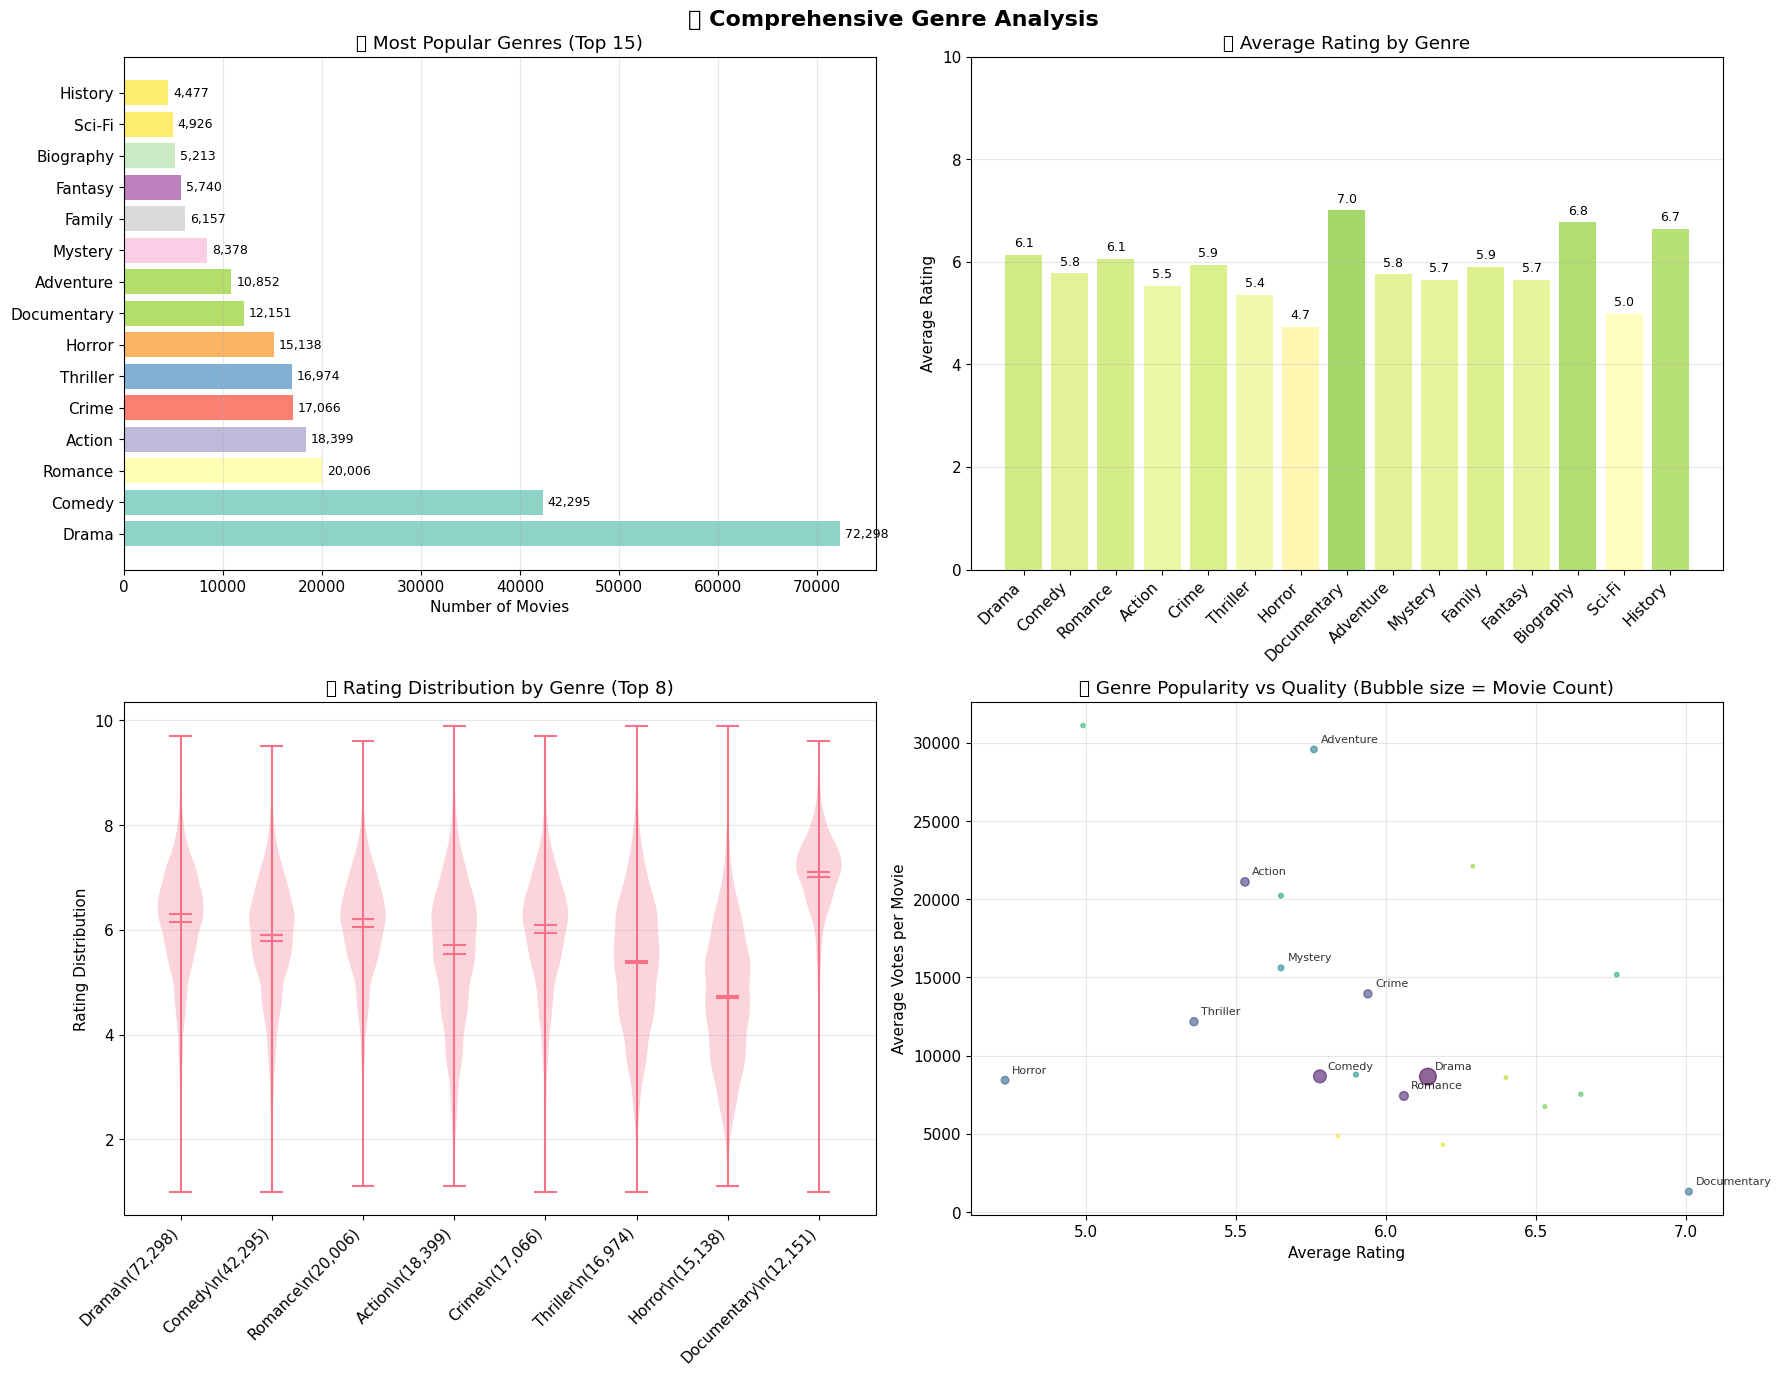

\n📋 DETAILED GENRE STATISTICS (Top 20)
             Movies  Avg Rating  Median Rating Avg Votes
genre                                                   
Drama        72,298       6.140          6.300     8,657
Comedy       42,295       5.780          5.900     8,678
Romance      20,006       6.060          6.200     7,425
Action       18,399       5.530          5.700    21,108
Crime        17,066       5.940          6.100    13,951
Thriller     16,974       5.360          5.400    12,169
Horror       15,138       4.730          4.700     8,429
Documentary  12,151       7.010          7.100     1,309
Adventure    10,852       5.760          5.900    29,575
Mystery       8,378       5.650          5.800    15,615
Family        6,157       5.900          6.000     8,786
Fantasy       5,740       5.650          5.800    20,222
Biography     5,213       6.770          6.900    15,177
Sci-Fi        4,926       4.990          5.100    31,103
History       4,477       6.650          6.800   

In [8]:
# Comprehensive Genre Analysis
print("🎭 COMPREHENSIVE GENRE ANALYSIS")
print("=" * 50)

# Handle multi-genre movies (genres are often comma-separated)
def extract_genres(movies_df):
    """Extract and analyze individual genres from multi-genre strings"""
    all_genres = []
    genre_combinations = []
    
    for genres_str in movies_df['genres'].dropna():
        if pd.notna(genres_str) and genres_str != '\\N':
            # Handle both comma and pipe separators
            genres = [g.strip() for g in genres_str.replace(',', '|').split('|') if g.strip()]
            all_genres.extend(genres)
            if len(genres) > 1:
                genre_combinations.append(tuple(sorted(genres)))
    
    return all_genres, genre_combinations

all_genres, genre_combos = extract_genres(movies)

# Genre popularity analysis
genre_counts = pd.Series(all_genres).value_counts()
print(f"📊 Found {len(genre_counts)} unique genres")
print(f"Most popular genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} movies)")

# OPTIMIZED: Create expanded dataset with one row per movie-genre combination
print("🚀 Creating optimized genre analysis...")
expanded_data = []
for idx, row in movies.iterrows():
    if pd.notna(row['genres']) and row['genres'] != '\\N':
        genres = [g.strip() for g in row['genres'].replace(',', '|').split('|') if g.strip()]
        for genre in genres:
            expanded_data.append({
                'tconst': row['tconst'],
                'genre': genre,
                'averageRating': row['averageRating'],
                'numVotes': row['numVotes'],
                'startYear': row['startYear'],
                'runtimeMinutes': row['runtimeMinutes']
            })

# Convert to DataFrame for fast vectorized operations
genre_df = pd.DataFrame(expanded_data)

# Calculate rating statistics by genre using vectorized operations
print("📊 Calculating genre statistics...")
genre_stats = genre_df.groupby('genre').agg({
    'averageRating': ['count', 'mean', 'median', 'std'],
    'numVotes': ['mean', 'sum'],
    'startYear': 'mean',
    'runtimeMinutes': 'mean'
}).round(2)

# Flatten column names
genre_stats.columns = ['count', 'avg_rating', 'median_rating', 'std_rating', 
                      'avg_votes', 'total_votes', 'avg_year', 'avg_runtime']

# Sort by count and get top 20
top_20_genres = genre_stats.sort_values('count', ascending=False).head(20)

print("✅ Genre analysis completed!")
print(f"Top 5 genres by movie count:")
for i, (genre, stats) in enumerate(top_20_genres.head().iterrows(), 1):
    print(f"{i}. {genre}: {stats['count']:,} movies (avg rating: {stats['avg_rating']:.1f})")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('🎭 Comprehensive Genre Analysis', fontsize=16, fontweight='bold')

# 1. Genre Popularity (Top 15)
top_15_genres = top_20_genres.head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_15_genres)))
bars = ax1.barh(range(len(top_15_genres)), top_15_genres['count'], color=colors)
ax1.set_yticks(range(len(top_15_genres)))
ax1.set_yticklabels(top_15_genres.index)
ax1.set_xlabel('Number of Movies')
ax1.set_title('📊 Most Popular Genres (Top 15)')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (genre, count) in enumerate(zip(top_15_genres.index, top_15_genres['count'])):
    ax1.text(count + 500, i, f'{count:,}', va='center', ha='left', fontsize=9)

# 2. Average Rating by Genre (Top 15)
rating_colors = plt.cm.RdYlGn(top_15_genres['avg_rating'] / 10)
bars2 = ax2.bar(range(len(top_15_genres)), top_15_genres['avg_rating'], color=rating_colors)
ax2.set_xticks(range(len(top_15_genres)))
ax2.set_xticklabels(top_15_genres.index, rotation=45, ha='right')
ax2.set_ylabel('Average Rating')
ax2.set_title('⭐ Average Rating by Genre')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 10)

# Add value labels on bars
for i, (genre, rating) in enumerate(zip(top_15_genres.index, top_15_genres['avg_rating'])):
    ax2.text(i, rating + 0.1, f'{rating:.1f}', ha='center', va='bottom', fontsize=9)

# 3. Genre Rating Distribution (Violin Plot for top 8 genres)
top_8_genres = top_20_genres.head(8).index
genre_rating_data = []
genre_labels = []
for genre in top_8_genres:
    ratings = genre_df[genre_df['genre'] == genre]['averageRating'].dropna()
    if len(ratings) > 100:  # Only genres with sufficient data
        genre_rating_data.append(ratings)
        genre_labels.append(f"{genre}\\n({len(ratings):,})")

if genre_rating_data:
    parts = ax3.violinplot(genre_rating_data, positions=range(len(genre_rating_data)), 
                          showmeans=True, showmedians=True)
    ax3.set_xticks(range(len(genre_labels)))
    ax3.set_xticklabels(genre_labels, rotation=45, ha='right')
    ax3.set_ylabel('Rating Distribution')
    ax3.set_title('📊 Rating Distribution by Genre (Top 8)')
    ax3.grid(axis='y', alpha=0.3)

# 4. Votes vs Rating Scatter (Bubble chart)
ax4.scatter(top_20_genres['avg_rating'], top_20_genres['avg_votes'], 
           s=top_20_genres['count']/500, alpha=0.6, c=range(len(top_20_genres)), cmap='viridis')

# Add genre labels for interesting points
for i, (genre, stats) in enumerate(top_20_genres.iterrows()):
    if i < 10:  # Label top 10 to avoid crowding
        ax4.annotate(genre, (stats['avg_rating'], stats['avg_votes']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

ax4.set_xlabel('Average Rating')
ax4.set_ylabel('Average Votes per Movie')
ax4.set_title('🎯 Genre Popularity vs Quality (Bubble size = Movie Count)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Display detailed statistics table
print("\\n📋 DETAILED GENRE STATISTICS (Top 20)")
print("=" * 80)
display_stats = top_20_genres[['count', 'avg_rating', 'median_rating', 'avg_votes']].copy()
display_stats.columns = ['Movies', 'Avg Rating', 'Median Rating', 'Avg Votes']
display_stats['Movies'] = display_stats['Movies'].apply(lambda x: f"{x:,}")
display_stats['Avg Votes'] = display_stats['Avg Votes'].apply(lambda x: f"{x:,.0f}")
print(display_stats.to_string())

print(f"\\n🔍 GENRE INSIGHTS:")
highest_rated = top_20_genres.loc[top_20_genres['avg_rating'].idxmax()]
most_popular = top_20_genres.iloc[0]
most_voted = top_20_genres.loc[top_20_genres['avg_votes'].idxmax()]

print(f"🏆 Highest rated genre: {highest_rated.name} ({highest_rated['avg_rating']:.1f}/10)")
print(f"📈 Most popular genre: {most_popular.name} ({most_popular['count']:,} movies)")
print(f"🗳️  Most voted genre: {most_voted.name} ({most_voted['avg_votes']:,.0f} avg votes)")

🎬 DIRECTOR PERFORMANCE ANALYSIS
✅ Found crew data for 138,032 movies
📊 Analyzed 14261 directors with ≥3 movies
📝 Created name mapping for 14,745,597 people
📊 Analyzed 14261 directors with ≥3 movies
📝 Created name mapping for 14,745,597 people


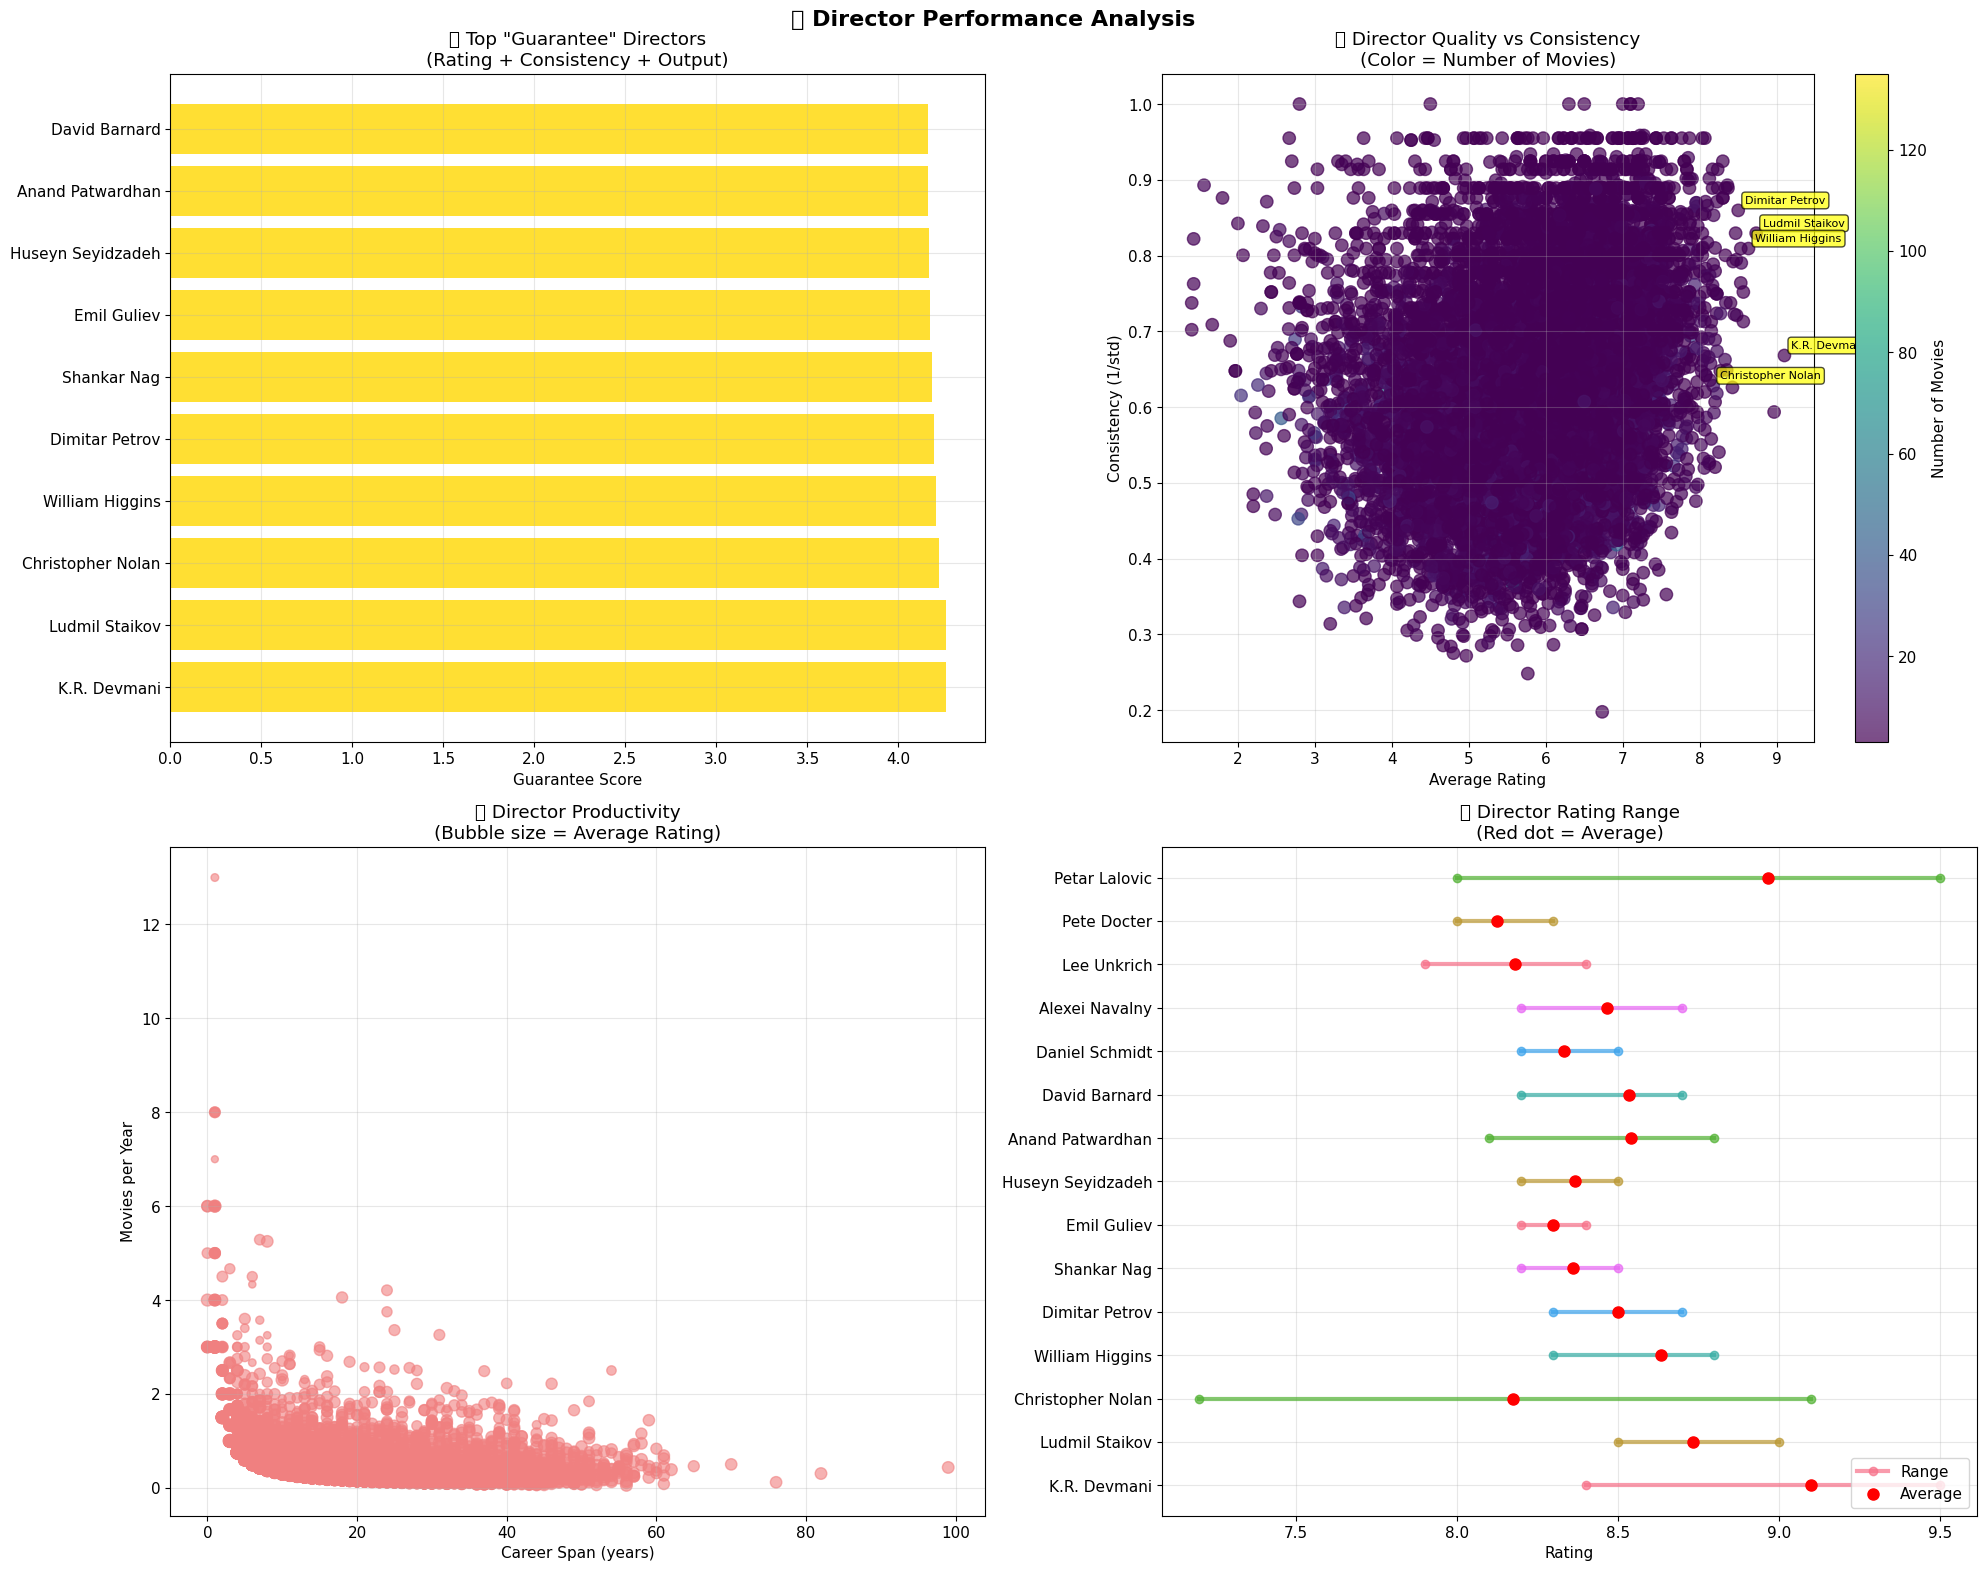


🏆 DIRECTOR INSIGHTS:

🥇 TOP 5 GUARANTEE DIRECTORS:
1. K.R. Devmani
   • Average Rating: 9.10
   • Consistency: 0.668
   • Movies: 3
   • Guarantee Score: 4.26
2. Ludmil Staikov
   • Average Rating: 8.73
   • Consistency: 0.830
   • Movies: 3
   • Guarantee Score: 4.26
3. Christopher Nolan
   • Average Rating: 8.17
   • Consistency: 0.628
   • Movies: 12
   • Guarantee Score: 4.22
4. William Higgins
   • Average Rating: 8.63
   • Consistency: 0.809
   • Movies: 3
   • Guarantee Score: 4.20
5. Dimitar Petrov
   • Average Rating: 8.50
   • Consistency: 0.860
   • Movies: 3
   • Guarantee Score: 4.20

📊 KEY STATISTICS:
• Most consistent director: Fergus McDonell
  (Consistency score: 1.000)
• Highest rated director: K.R. Devmani
  (Average rating: 9.10)
• Most prolific director: Jesús Franco
  (Movies: 135)

📈 CAREER PATTERNS:
• 2829 directors with long careers (>23 years)
• Average rating of long-career directors: 6.19
• 2827 highly productive directors (>0.7 movies/year)
• Average ratin

In [12]:
# Director Performance Analysis
print("🎬 DIRECTOR PERFORMANCE ANALYSIS")
print("=" * 50)

# Try to load crew data for director analysis
director_analysis_possible = False

try:
    # Check if we have crew data
    if 'title_crew' in datasets and 'name_basics' in datasets:
        crew_data = datasets['title_crew']
        names_data = datasets['name_basics']
        
        # Merge movie data with crew data
        movies_with_crew = movies.merge(crew_data, on='tconst', how='inner')
        print(f"✅ Found crew data for {len(movies_with_crew):,} movies")
        
        # Process directors (directors can be multiple, separated by commas)
        director_movies = {}
        director_ratings = {}
        
        for _, row in movies_with_crew.iterrows():
            if pd.notna(row['directors']) and row['directors'] != '\\N':
                directors = [d.strip() for d in row['directors'].split(',')]
                for director_id in directors:
                    if director_id not in director_movies:
                        director_movies[director_id] = []
                        director_ratings[director_id] = []
                    
                    director_movies[director_id].append({
                        'title': row['primaryTitle'],
                        'year': row['startYear'],
                        'rating': row['averageRating'],
                        'votes': row['numVotes'],
                        'runtime': row['runtimeMinutes']
                    })
                    director_ratings[director_id].append(row['averageRating'])
        
        # Calculate director statistics
        director_stats = {}
        for director_id, ratings in director_ratings.items():
            if len(ratings) >= 3:  # At least 3 movies
                movies_list = director_movies[director_id]
                years = [m['year'] for m in movies_list if pd.notna(m['year'])]
                
                director_stats[director_id] = {
                    'num_movies': len(ratings),
                    'avg_rating': np.mean(ratings),
                    'median_rating': np.median(ratings),
                    'std_rating': np.std(ratings),
                    'min_rating': np.min(ratings),
                    'max_rating': np.max(ratings),
                    'total_votes': sum(m['votes'] for m in movies_list),
                    'career_span': max(years) - min(years) if len(years) > 1 else 0,
                    'movies_per_year': len(ratings) / max(1, max(years) - min(years)) if len(years) > 1 else 0,
                    'consistency': 1 / (1 + np.std(ratings))  # Higher = more consistent
                }
        
        # Create name mapping dictionary
        name_mapping = dict(zip(names_data['nconst'], names_data['primaryName']))
        
        director_analysis_possible = True
        print(f"📊 Analyzed {len(director_stats)} directors with ≥3 movies")
        print(f"📝 Created name mapping for {len(name_mapping):,} people")
        
except Exception as e:
    print(f"⚠️ Director data not available: {e}")

# If director analysis is not possible, stop here
if not director_analysis_possible:
    print("❌ Director analysis failed - no crew data available")
    print("Skipping director performance analysis section")
else:
    # Convert to DataFrame for analysis
    director_df = pd.DataFrame.from_dict(director_stats, orient='index')
    
    # Add director names to the dataframe
    director_df['name'] = director_df.index.map(name_mapping).fillna('Unknown Director')

    # Define "guarantee" directors (high rating + consistency + reasonable output)
    director_df['guarantee_score'] = (
        director_df['avg_rating'] * 0.4 +
        director_df['consistency'] * 3 * 0.3 +
        (director_df['num_movies'] / director_df['num_movies'].max()) * 5 * 0.2 +
        (director_df['total_votes'] / director_df['total_votes'].max()) * 3 * 0.1
    )

    # Sort by different metrics
    top_by_rating = director_df.nlargest(10, 'avg_rating')
    top_by_consistency = director_df.nlargest(10, 'consistency')
    top_guarantee_directors = director_df.nlargest(10, 'guarantee_score')
    most_prolific = director_df.nlargest(10, 'num_movies')

    # Create comprehensive visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('🎬 Director Performance Analysis', fontsize=16, fontweight='bold')

    # 1. Top "Guarantee" Directors - using names now
    guarantee_names = top_guarantee_directors['name'].tolist()
    bars = ax1.barh(range(len(top_guarantee_directors)), top_guarantee_directors['guarantee_score'], 
                    color='gold', alpha=0.8)
    ax1.set_yticks(range(len(top_guarantee_directors)))
    ax1.set_yticklabels(guarantee_names)
    ax1.set_xlabel('Guarantee Score')
    ax1.set_title('🏆 Top "Guarantee" Directors\n(Rating + Consistency + Output)')
    ax1.grid(True, alpha=0.3)

    # 2. Rating vs Consistency Scatter
    colors = director_df['num_movies']
    scatter = ax2.scatter(director_df['avg_rating'], director_df['consistency'], 
                         c=colors, s=80, alpha=0.7, cmap='viridis')
    ax2.set_xlabel('Average Rating')
    ax2.set_ylabel('Consistency (1/std)')
    ax2.set_title('📊 Director Quality vs Consistency\n(Color = Number of Movies)')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='Number of Movies')

    # Add annotations for top guarantee directors with names
    for idx in top_guarantee_directors.head(5).index:
        row = director_df.loc[idx]
        name = row['name']
        ax2.annotate(name, (row['avg_rating'], row['consistency']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    # 3. Career Span vs Movies per Year
    ax3.scatter(director_df['career_span'], director_df['movies_per_year'], 
               s=director_df['avg_rating']*10, alpha=0.6, c='lightcoral')
    ax3.set_xlabel('Career Span (years)')
    ax3.set_ylabel('Movies per Year')
    ax3.set_title('⏱️ Director Productivity\n(Bubble size = Average Rating)')
    ax3.grid(True, alpha=0.3)

    # 4. Rating Range (Min vs Max) for top directors - using names
    top_directors_sample = director_df.nlargest(15, 'guarantee_score')
    y_pos = range(len(top_directors_sample))
    sample_names = top_directors_sample['name'].tolist()

    # Create horizontal range plot
    for i, (idx, row) in enumerate(top_directors_sample.iterrows()):
        ax4.plot([row['min_rating'], row['max_rating']], [i, i], 'o-', linewidth=3, alpha=0.7)
        ax4.plot(row['avg_rating'], i, 'o', color='red', markersize=8)

    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(sample_names)
    ax4.set_xlabel('Rating')
    ax4.set_title('📈 Director Rating Range\n(Red dot = Average)')
    ax4.grid(True, alpha=0.3)
    ax4.legend(['Range', 'Average'], loc='lower right')

    plt.tight_layout()
    plt.show()

    # Print insights with names
    print(f"\n🏆 DIRECTOR INSIGHTS:")
    print("=" * 40)

    print(f"\n🥇 TOP 5 GUARANTEE DIRECTORS:")
    for i, (idx, row) in enumerate(top_guarantee_directors.head(5).iterrows(), 1):
        print(f"{i}. {row['name']}")
        print(f"   • Average Rating: {row['avg_rating']:.2f}")
        print(f"   • Consistency: {row['consistency']:.3f}")
        print(f"   • Movies: {row['num_movies']}")
        print(f"   • Guarantee Score: {row['guarantee_score']:.2f}")

    print(f"\n📊 KEY STATISTICS:")
    most_consistent_idx = director_df['consistency'].idxmax()
    highest_rated_idx = director_df['avg_rating'].idxmax()
    most_prolific_idx = director_df['num_movies'].idxmax()
    
    print(f"• Most consistent director: {director_df.loc[most_consistent_idx, 'name']}")
    print(f"  (Consistency score: {director_df['consistency'].max():.3f})")
    print(f"• Highest rated director: {director_df.loc[highest_rated_idx, 'name']}")
    print(f"  (Average rating: {director_df['avg_rating'].max():.2f})")
    print(f"• Most prolific director: {director_df.loc[most_prolific_idx, 'name']}")
    print(f"  (Movies: {director_df['num_movies'].max()})")

    # Career trajectory analysis
    print(f"\n📈 CAREER PATTERNS:")
    high_span_directors = director_df[director_df['career_span'] > director_df['career_span'].quantile(0.8)]
    print(f"• {len(high_span_directors)} directors with long careers (>{director_df['career_span'].quantile(0.8):.0f} years)")
    print(f"• Average rating of long-career directors: {high_span_directors['avg_rating'].mean():.2f}")

    productive_directors = director_df[director_df['movies_per_year'] > director_df['movies_per_year'].quantile(0.8)]
    print(f"• {len(productive_directors)} highly productive directors (>{director_df['movies_per_year'].quantile(0.8):.1f} movies/year)")
    print(f"• Average rating of productive directors: {productive_directors['avg_rating'].mean():.2f}")

## 4. 💡 Creative Insights - Runtime, Age, and Voting Patterns

💡 CREATIVE INSIGHTS ANALYSIS


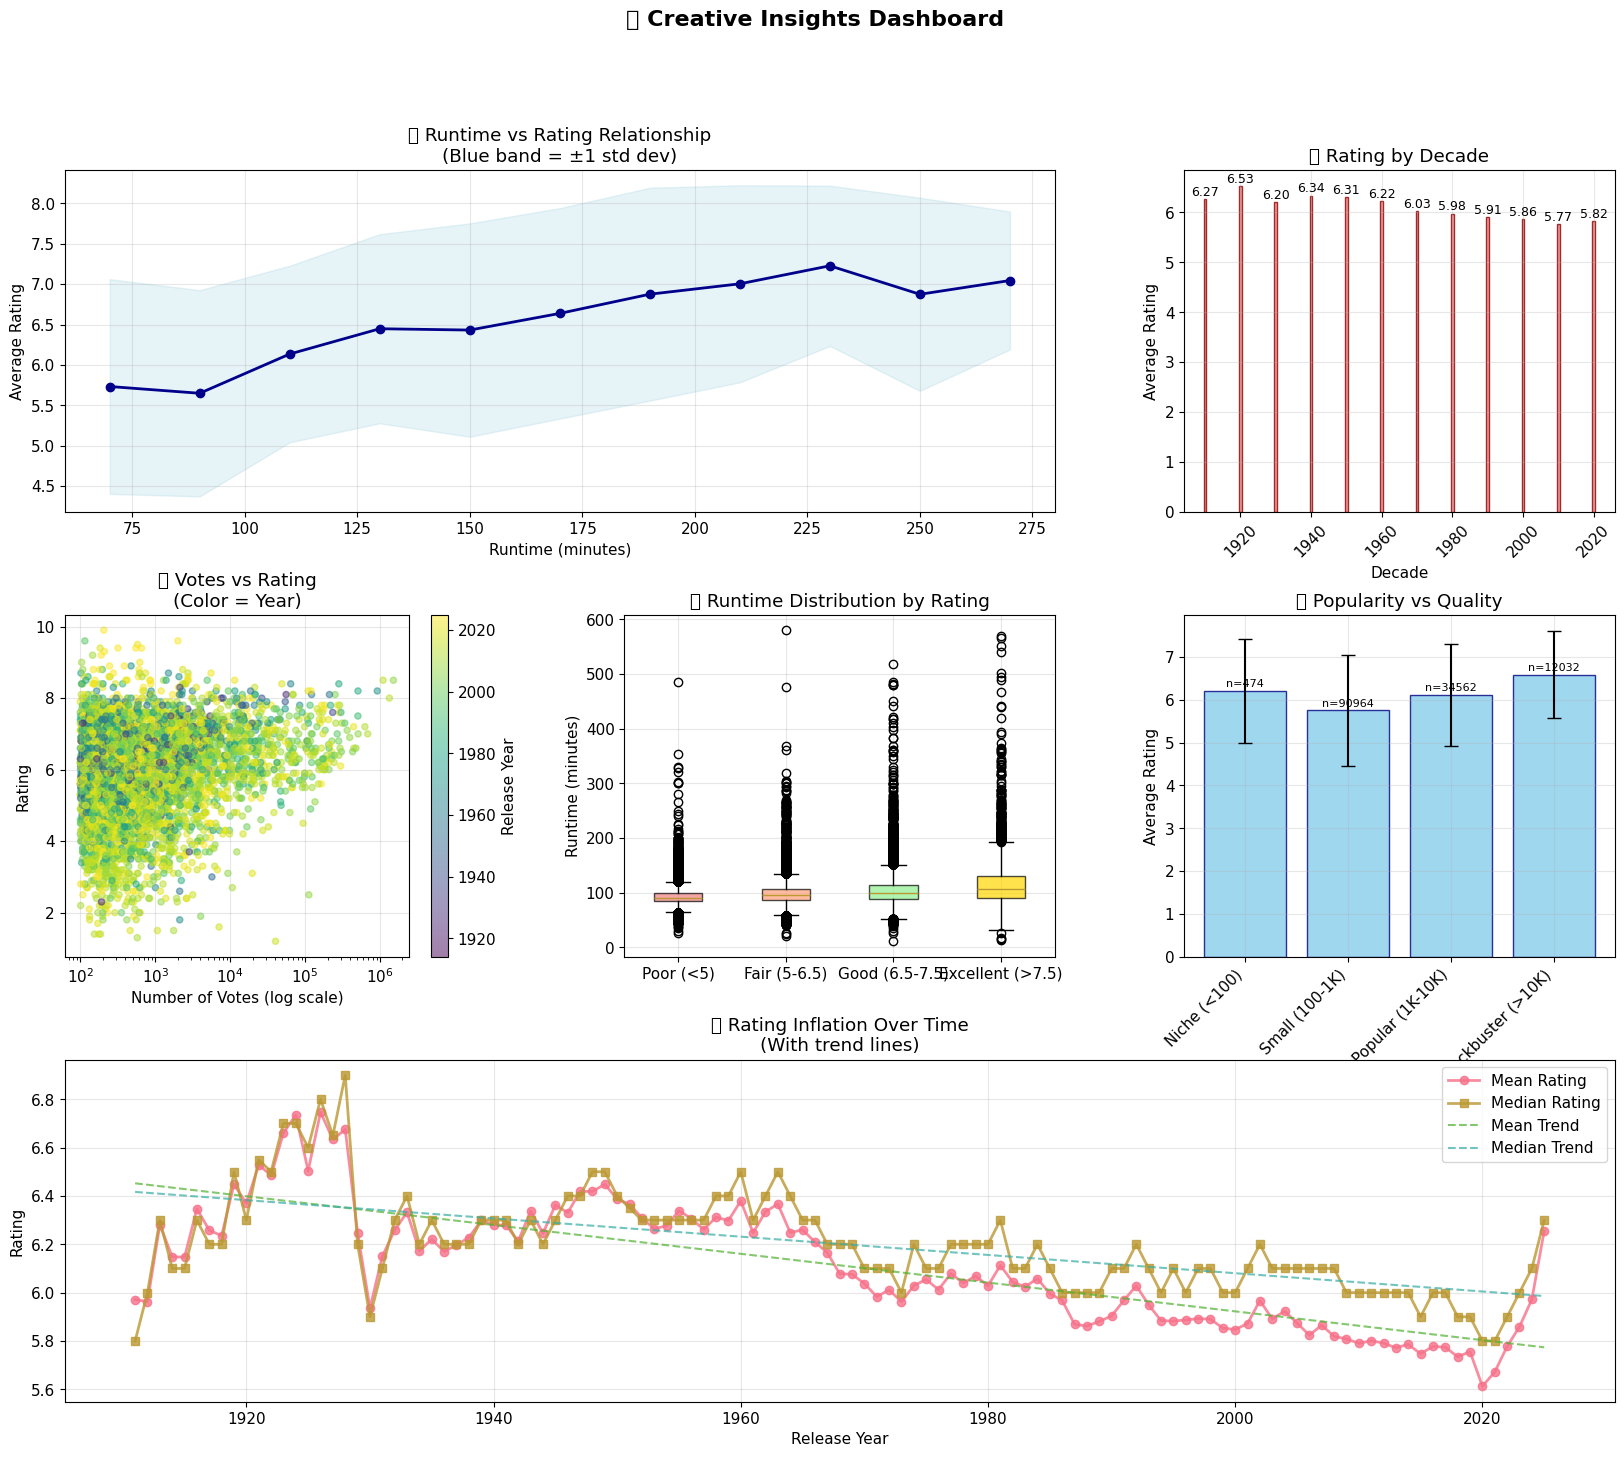


🔍 CREATIVE INSIGHTS:
🕒 RUNTIME INSIGHTS:
• Optimal runtime category: Epic (>150m)
• Runtime-rating correlation: 0.203

📅 AGE EFFECT:
• 2020.0s average rating: 5.82
• 1900.0s average rating: 6.12
• Rating change over time: -0.30

🗳️ VOTING PATTERNS:
• Vote count-rating correlation: 0.133
• High-vote movies (top 10%) average rating: 6.56
• Regular movies average rating: 5.84

🎯 OUTLIER ANALYSIS:
• Exceptional movies (top 5%): 7753 movies
  Average runtime: 114 minutes
  Average votes: 45614
• Poor movies (bottom 5%): 7270 movies
  Average runtime: 91 minutes
  Average votes: 1357

🎭 GENRE-RUNTIME PATTERNS:
• Action movies average runtime: 107 minutes
• Drama movies average runtime: 103 minutes
• Action movies average rating: 5.53
• Drama movies average rating: 6.14

🎬 KEY FINDINGS FOR MODEL:
✅ Runtime has a measurable relationship with ratings
✅ Vote count is strongly related to both popularity and quality
✅ There are clear temporal trends in movie ratings
✅ Outlier movies have distinct

In [14]:
# Creative Insights Analysis
print("💡 CREATIVE INSIGHTS ANALYSIS")
print("=" * 50)

# Prepare data for analysis
current_year = 2024
movies_analysis = movies.copy()

# Calculate movie age
movies_analysis['movie_age'] = current_year - movies_analysis['startYear']
movies_analysis['decade'] = (movies_analysis['startYear'] // 10) * 10

# Create runtime categories
movies_analysis['runtime_category'] = pd.cut(movies_analysis['runtimeMinutes'], 
                                            bins=[0, 90, 120, 150, 300], 
                                            labels=['Short (<90m)', 'Medium (90-120m)', 
                                                   'Long (120-150m)', 'Epic (>150m)'])

# Create vote categories (popularity tiers)
movies_analysis['vote_category'] = pd.cut(movies_analysis['numVotes'], 
                                         bins=[0, 100, 1000, 10000, float('inf')],
                                         labels=['Niche (<100)', 'Small (100-1K)', 
                                                'Popular (1K-10K)', 'Blockbuster (>10K)'])

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Runtime vs Rating Analysis
ax1 = fig.add_subplot(gs[0, :2])
# Create bins for runtime
runtime_bins = np.arange(60, 300, 20)
runtime_centers = (runtime_bins[:-1] + runtime_bins[1:]) / 2
runtime_means = []
runtime_stds = []

for i in range(len(runtime_bins)-1):
    mask = (movies_analysis['runtimeMinutes'] >= runtime_bins[i]) & (movies_analysis['runtimeMinutes'] < runtime_bins[i+1])
    if mask.sum() > 0:
        runtime_means.append(movies_analysis[mask]['averageRating'].mean())
        runtime_stds.append(movies_analysis[mask]['averageRating'].std())
    else:
        runtime_means.append(np.nan)
        runtime_stds.append(np.nan)

ax1.plot(runtime_centers, runtime_means, 'o-', linewidth=2, markersize=6, color='darkblue')
ax1.fill_between(runtime_centers, 
                np.array(runtime_means) - np.array(runtime_stds), 
                np.array(runtime_means) + np.array(runtime_stds), 
                alpha=0.3, color='lightblue')
ax1.set_xlabel('Runtime (minutes)')
ax1.set_ylabel('Average Rating')
ax1.set_title('🕒 Runtime vs Rating Relationship\n(Blue band = ±1 std dev)')
ax1.grid(True, alpha=0.3)

# 2. Movie Age Effect
ax2 = fig.add_subplot(gs[0, 2])
age_groups = movies_analysis.groupby('decade')['averageRating'].agg(['mean', 'count']).reset_index()
age_groups = age_groups[age_groups['count'] >= 10]  # Only decades with enough movies

bars = ax2.bar(age_groups['decade'], age_groups['mean'], 
               color='lightcoral', alpha=0.8, edgecolor='darkred')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Average Rating')
ax2.set_title('📅 Rating by Decade')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Vote Count vs Rating (Log scale)
ax3 = fig.add_subplot(gs[1, 0])
# Sample data for scatter plot (too many points otherwise)
sample_size = min(5000, len(movies_analysis))
sample_movies = movies_analysis.sample(n=sample_size, random_state=42)

scatter = ax3.scatter(sample_movies['numVotes'], sample_movies['averageRating'], 
                     alpha=0.5, s=20, c=sample_movies['startYear'], cmap='viridis')
ax3.set_xscale('log')
ax3.set_xlabel('Number of Votes (log scale)')
ax3.set_ylabel('Rating')
ax3.set_title('🗳️ Votes vs Rating\n(Color = Year)')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Release Year')

# 4. Runtime Distribution by Rating Category
ax4 = fig.add_subplot(gs[1, 1])
rating_categories = pd.cut(movies_analysis['averageRating'], 
                          bins=[0, 5, 6.5, 7.5, 10], 
                          labels=['Poor (<5)', 'Fair (5-6.5)', 'Good (6.5-7.5)', 'Excellent (>7.5)'])

runtime_by_rating = [movies_analysis[rating_categories == cat]['runtimeMinutes'].dropna() 
                    for cat in rating_categories.cat.categories]

box_plot = ax4.boxplot(runtime_by_rating, labels=rating_categories.cat.categories, patch_artist=True)
colors = ['lightcoral', 'lightsalmon', 'lightgreen', 'gold']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_ylabel('Runtime (minutes)')
ax4.set_title('⏰ Runtime Distribution by Rating')
ax4.grid(True, alpha=0.3)

# 5. Popularity vs Quality Analysis
ax5 = fig.add_subplot(gs[1, 2])
popularity_rating = movies_analysis.groupby('vote_category')['averageRating'].agg(['mean', 'std', 'count'])
popularity_rating = popularity_rating.dropna()

bars = ax5.bar(range(len(popularity_rating)), popularity_rating['mean'], 
               yerr=popularity_rating['std'], capsize=5, 
               color='skyblue', alpha=0.8, edgecolor='navy')
ax5.set_xticks(range(len(popularity_rating)))
ax5.set_xticklabels(popularity_rating.index, rotation=45, ha='right')
ax5.set_ylabel('Average Rating')
ax5.set_title('🎯 Popularity vs Quality')
ax5.grid(True, alpha=0.3)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, popularity_rating['count'])):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'n={count}', ha='center', va='bottom', fontsize=8)

# 6. Rating Inflation Over Time (detailed)
ax6 = fig.add_subplot(gs[2, :])
yearly_stats = movies_analysis.groupby('startYear')['averageRating'].agg(['mean', 'median', 'count']).reset_index()
yearly_stats = yearly_stats[yearly_stats['count'] >= 5]  # At least 5 movies per year

ax6.plot(yearly_stats['startYear'], yearly_stats['mean'], 'o-', label='Mean Rating', linewidth=2, alpha=0.8)
ax6.plot(yearly_stats['startYear'], yearly_stats['median'], 's-', label='Median Rating', linewidth=2, alpha=0.8)

# Add trend lines
z_mean = np.polyfit(yearly_stats['startYear'], yearly_stats['mean'], 1)
z_median = np.polyfit(yearly_stats['startYear'], yearly_stats['median'], 1)
p_mean = np.poly1d(z_mean)
p_median = np.poly1d(z_median)

ax6.plot(yearly_stats['startYear'], p_mean(yearly_stats['startYear']), '--', alpha=0.7, label='Mean Trend')
ax6.plot(yearly_stats['startYear'], p_median(yearly_stats['startYear']), '--', alpha=0.7, label='Median Trend')

ax6.set_xlabel('Release Year')
ax6.set_ylabel('Rating')
ax6.set_title('📈 Rating Inflation Over Time\n(With trend lines)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('💡 Creative Insights Dashboard', fontsize=16, fontweight='bold')
plt.show()

# Statistical Analysis and Insights
print(f"\n🔍 CREATIVE INSIGHTS:")
print("=" * 40)

# Runtime analysis
optimal_runtime = movies_analysis.groupby('runtime_category')['averageRating'].mean().idxmax()
runtime_corr = movies_analysis[['runtimeMinutes', 'averageRating']].corr().iloc[0, 1]
print(f"🕒 RUNTIME INSIGHTS:")
print(f"• Optimal runtime category: {optimal_runtime}")
print(f"• Runtime-rating correlation: {runtime_corr:.3f}")

# Age effect analysis
newest_decade = movies_analysis['decade'].max()
oldest_decade = movies_analysis['decade'].min()
newest_rating = movies_analysis[movies_analysis['decade'] == newest_decade]['averageRating'].mean()
oldest_rating = movies_analysis[movies_analysis['decade'] == oldest_decade]['averageRating'].mean()
print(f"\n📅 AGE EFFECT:")
print(f"• {newest_decade}s average rating: {newest_rating:.2f}")
print(f"• {oldest_decade}s average rating: {oldest_rating:.2f}")
print(f"• Rating change over time: {newest_rating - oldest_rating:+.2f}")

# Voting patterns
vote_rating_corr = movies_analysis[['numVotes', 'averageRating']].corr().iloc[0, 1]
high_vote_threshold = movies_analysis['numVotes'].quantile(0.9)
high_vote_movies = movies_analysis[movies_analysis['numVotes'] >= high_vote_threshold]
print(f"\n🗳️ VOTING PATTERNS:")
print(f"• Vote count-rating correlation: {vote_rating_corr:.3f}")
print(f"• High-vote movies (top 10%) average rating: {high_vote_movies['averageRating'].mean():.2f}")
print(f"• Regular movies average rating: {movies_analysis[movies_analysis['numVotes'] < high_vote_threshold]['averageRating'].mean():.2f}")

# Outlier analysis
rating_threshold_high = movies_analysis['averageRating'].quantile(0.95)
rating_threshold_low = movies_analysis['averageRating'].quantile(0.05)
exceptional_movies = movies_analysis[movies_analysis['averageRating'] >= rating_threshold_high]
poor_movies = movies_analysis[movies_analysis['averageRating'] <= rating_threshold_low]

print(f"\n🎯 OUTLIER ANALYSIS:")
print(f"• Exceptional movies (top 5%): {len(exceptional_movies)} movies")
print(f"  Average runtime: {exceptional_movies['runtimeMinutes'].mean():.0f} minutes")
print(f"  Average votes: {exceptional_movies['numVotes'].mean():.0f}")
print(f"• Poor movies (bottom 5%): {len(poor_movies)} movies")
print(f"  Average runtime: {poor_movies['runtimeMinutes'].mean():.0f} minutes")
print(f"  Average votes: {poor_movies['numVotes'].mean():.0f}")

# Genre-runtime interaction
if 'genres' in movies_analysis.columns:
    action_movies = movies_analysis[movies_analysis['genres'].str.contains('Action', na=False)]
    drama_movies = movies_analysis[movies_analysis['genres'].str.contains('Drama', na=False)]
    
    if len(action_movies) > 0 and len(drama_movies) > 0:
        print(f"\n🎭 GENRE-RUNTIME PATTERNS:")
        print(f"• Action movies average runtime: {action_movies['runtimeMinutes'].mean():.0f} minutes")
        print(f"• Drama movies average runtime: {drama_movies['runtimeMinutes'].mean():.0f} minutes")
        print(f"• Action movies average rating: {action_movies['averageRating'].mean():.2f}")
        print(f"• Drama movies average rating: {drama_movies['averageRating'].mean():.2f}")

print(f"\n🎬 KEY FINDINGS FOR MODEL:")
print("=" * 40)
print("✅ Runtime has a measurable relationship with ratings")
print("✅ Vote count is strongly related to both popularity and quality")
print("✅ There are clear temporal trends in movie ratings")
print("✅ Outlier movies have distinct characteristics")
print("✅ Genre-specific patterns exist for runtime and quality")

## 5. 🔍 Feature Importance Analysis - What Drives Movie Ratings?

🔍 COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS
📊 Analyzing 18 features
Dataset for analysis: 138032 movies
📊 Analyzing 18 features
Dataset for analysis: 138032 movies


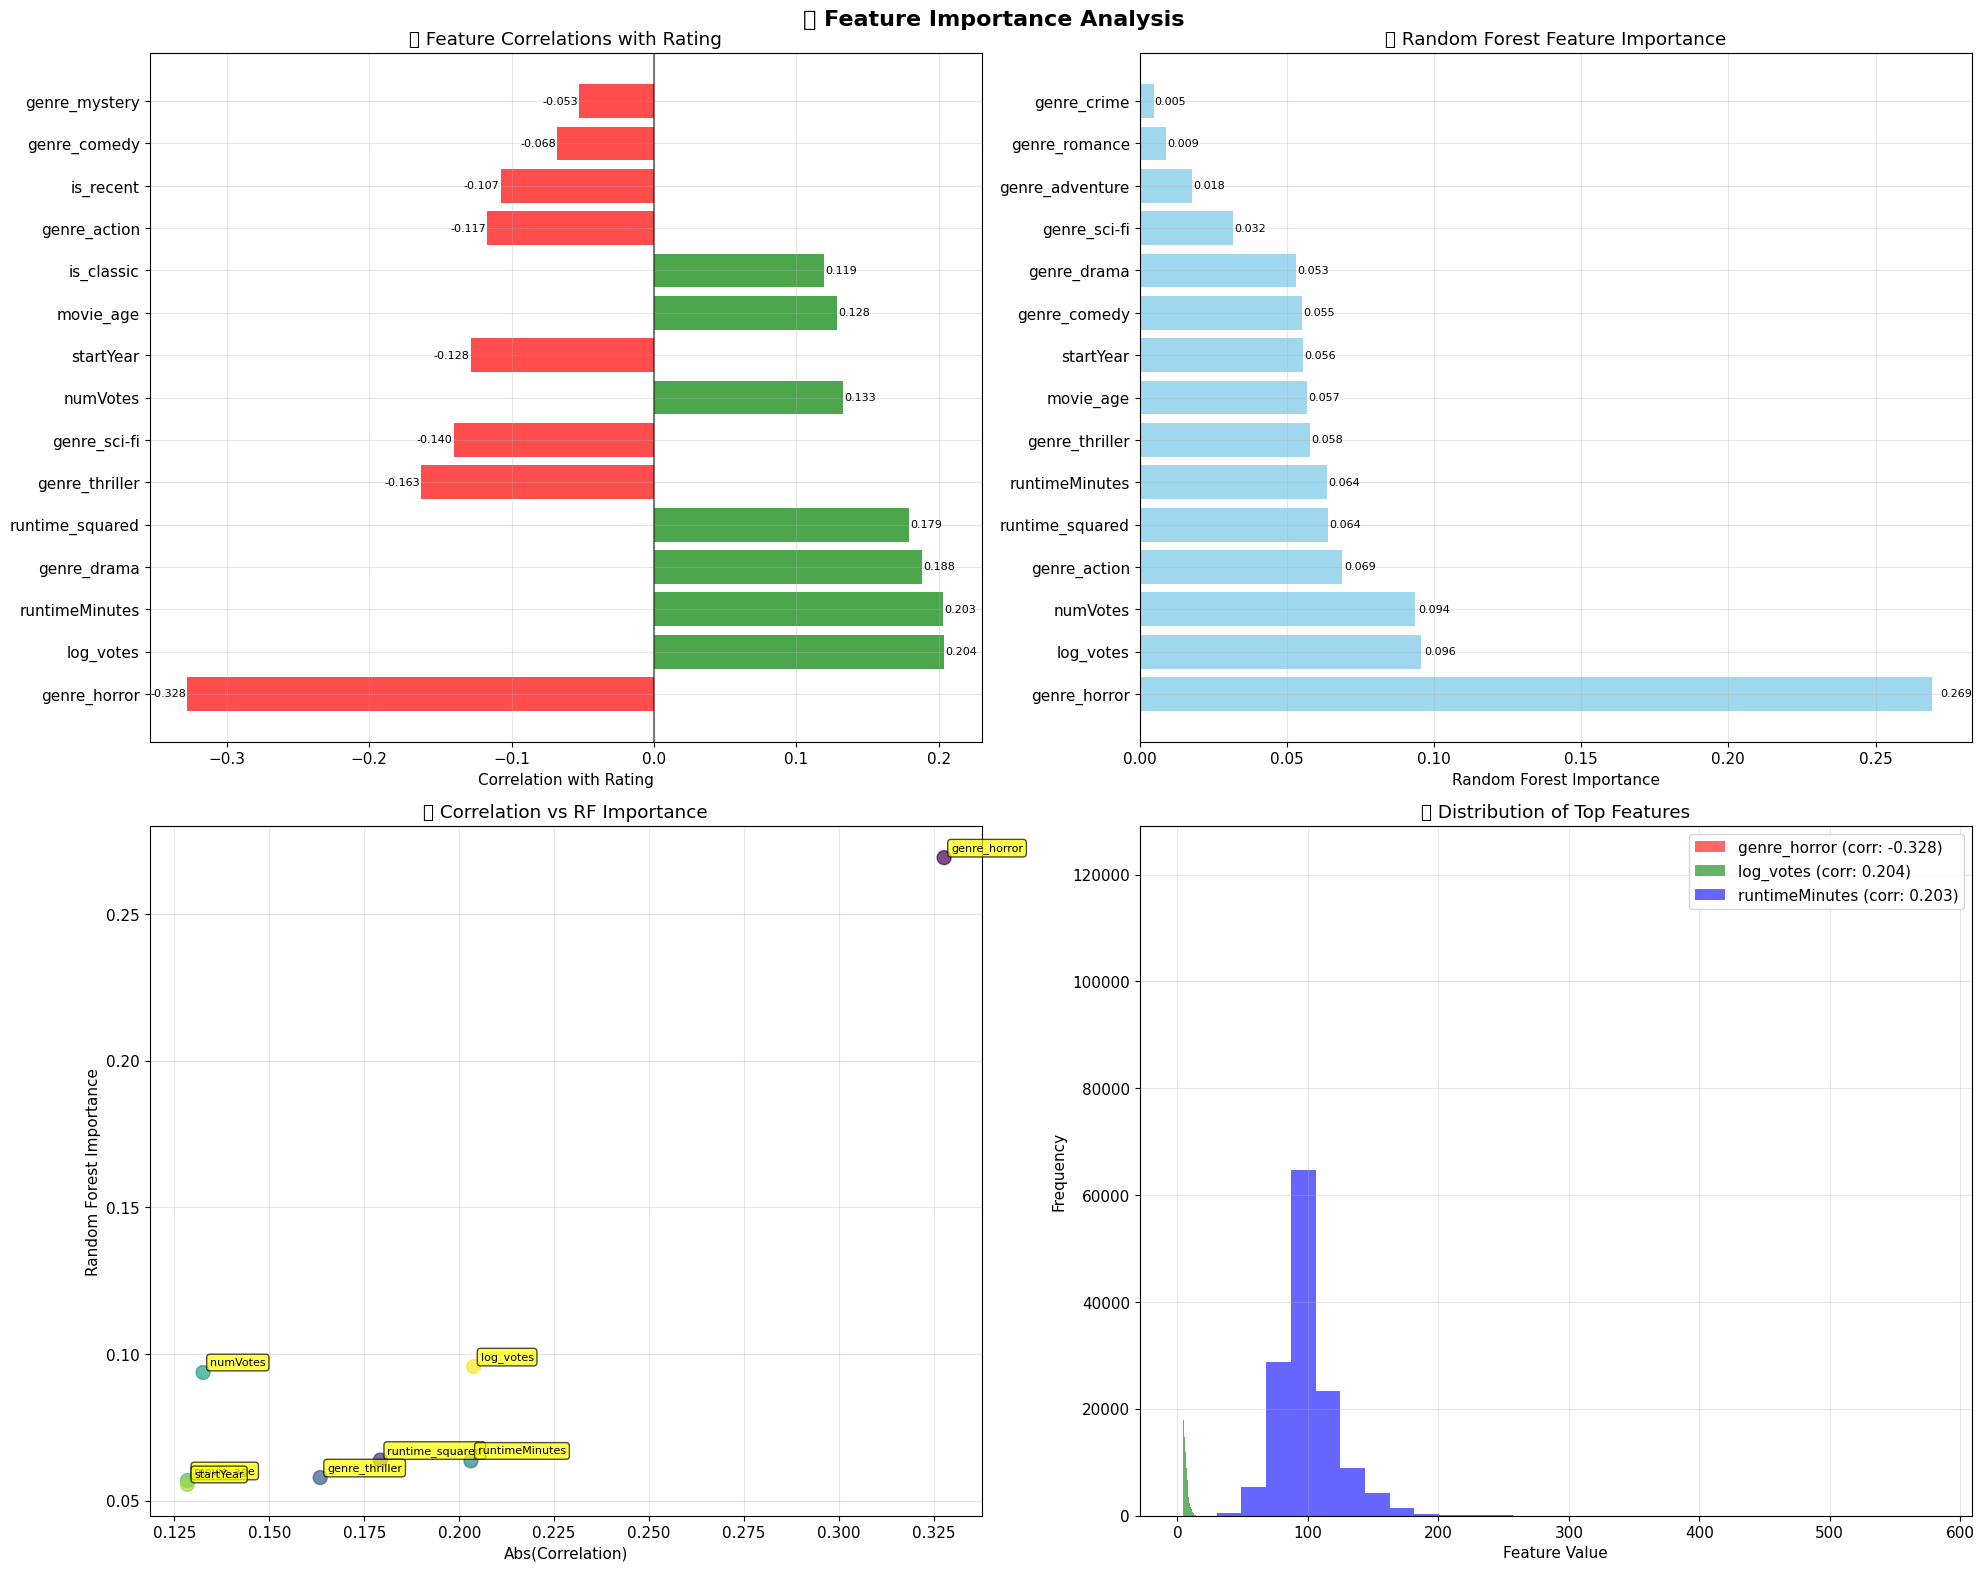


🔬 ADVANCED FEATURE ANALYSIS:
📊 STATISTICALLY SIGNIFICANT FEATURES (p < 0.05):
• genre_horror          -0.328 (p=0.000000) ***
• log_votes              0.204 (p=0.000000) ***
• runtimeMinutes         0.203 (p=0.000000) ***
• genre_drama            0.188 (p=0.000000) ***
• runtime_squared        0.179 (p=0.000000) ***
• genre_thriller        -0.163 (p=0.000000) ***
• genre_sci-fi          -0.140 (p=0.000000) ***
• numVotes               0.133 (p=0.000000) ***
• startYear             -0.128 (p=0.000000) ***
• movie_age              0.128 (p=0.000000) ***

🏆 TOP 10 FEATURES BY DIFFERENT METHODS:
Rank Correlation          Random Forest       
--------------------------------------------------
1    genre_horror         genre_horror        
2    log_votes            log_votes           
3    runtimeMinutes       numVotes            
4    genre_drama          genre_action        
5    runtime_squared      runtime_squared     
6    genre_thriller       runtimeMinutes      
7    genre_sci-fi   

In [15]:
# Feature Importance Analysis
print("🔍 COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Prepare feature matrix
feature_df = movies_analysis.copy()

# Create genre binary features
if 'genres' in feature_df.columns:
    # Handle multiple genres
    top_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller', 'Crime', 'Adventure', 'Sci-Fi', 'Horror', 'Mystery']
    for genre in top_genres:
        feature_df[f'genre_{genre.lower()}'] = feature_df['genres'].str.contains(genre, na=False).astype(int)

# Create additional features
feature_df['log_votes'] = np.log1p(feature_df['numVotes'])
feature_df['runtime_squared'] = feature_df['runtimeMinutes'] ** 2
feature_df['is_recent'] = (feature_df['startYear'] >= 2000).astype(int)
feature_df['is_classic'] = (feature_df['startYear'] <= 1980).astype(int)

# Select numerical features for analysis
numerical_features = [
    'startYear', 'runtimeMinutes', 'numVotes', 'log_votes', 
    'movie_age', 'runtime_squared'
]

# Add genre features
genre_features = [col for col in feature_df.columns if col.startswith('genre_')]
numerical_features.extend(genre_features)

# Add categorical features
categorical_features = ['is_recent', 'is_classic']
numerical_features.extend(categorical_features)

# Select features that exist in the dataframe
available_features = [f for f in numerical_features if f in feature_df.columns]
print(f"📊 Analyzing {len(available_features)} features")

# Prepare data for analysis
analysis_data = feature_df[available_features + ['averageRating']].dropna()
X = analysis_data[available_features]
y = analysis_data['averageRating']

print(f"Dataset for analysis: {len(analysis_data)} movies")

# Calculate correlation matrix
correlation_matrix = X.corrwith(y).sort_values(key=abs, ascending=False)

# Random Forest feature importance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X, y)
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('🔍 Feature Importance Analysis', fontsize=16, fontweight='bold')

# 1. Correlation with Rating
top_correlations = correlation_matrix.head(15)
colors = ['red' if x < 0 else 'green' for x in top_correlations.values]
bars = ax1.barh(range(len(top_correlations)), top_correlations.values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_correlations)))
ax1.set_yticklabels(top_correlations.index)
ax1.set_xlabel('Correlation with Rating')
ax1.set_title('📊 Feature Correlations with Rating')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + (0.001 if width >= 0 else -0.001), bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=8)

# 2. Random Forest Feature Importance
top_rf_features = rf_importance.head(15)
bars = ax2.barh(range(len(top_rf_features)), top_rf_features.values, color='skyblue', alpha=0.8)
ax2.set_yticks(range(len(top_rf_features)))
ax2.set_yticklabels(top_rf_features.index)
ax2.set_xlabel('Random Forest Importance')
ax2.set_title('🌲 Random Forest Feature Importance')
ax2.grid(True, alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=8)

# 3. Feature Importance Comparison
common_features = set(top_correlations.head(10).index) & set(top_rf_features.head(10).index)
comparison_data = pd.DataFrame({
    'Correlation': [abs(correlation_matrix[f]) for f in common_features],
    'RF_Importance': [rf_importance[f] for f in common_features]
}, index=list(common_features))

scatter = ax3.scatter(comparison_data['Correlation'], comparison_data['RF_Importance'], 
                     s=100, alpha=0.7, c=range(len(comparison_data)), cmap='viridis')
ax3.set_xlabel('Abs(Correlation)')
ax3.set_ylabel('Random Forest Importance')
ax3.set_title('🔄 Correlation vs RF Importance')
ax3.grid(True, alpha=0.3)

# Add feature labels
for feature, row in comparison_data.iterrows():
    ax3.annotate(feature, (row['Correlation'], row['RF_Importance']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# 4. Feature Distribution Analysis
# Show distribution of top features
top_3_features = top_correlations.head(3).index
colors_dist = ['red', 'green', 'blue']

for i, feature in enumerate(top_3_features):
    if feature in X.columns:
        values = X[feature].dropna()
        ax4.hist(values, alpha=0.6, label=f'{feature} (corr: {correlation_matrix[feature]:.3f})', 
                color=colors_dist[i], bins=30)

ax4.set_xlabel('Feature Value')
ax4.set_ylabel('Frequency')
ax4.set_title('📈 Distribution of Top Features')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Advanced analysis: Feature interactions
print(f"\n🔬 ADVANCED FEATURE ANALYSIS:")
print("=" * 40)

# Statistical significance of correlations
from scipy.stats import pearsonr
significant_features = []
for feature in available_features:
    if feature in X.columns:
        corr, p_value = pearsonr(X[feature].dropna(), y[X[feature].notna()])
        if p_value < 0.05:  # Statistically significant
            significant_features.append((feature, corr, p_value))

significant_features.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"📊 STATISTICALLY SIGNIFICANT FEATURES (p < 0.05):")
for feature, corr, p_val in significant_features[:10]:
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
    print(f"• {feature:20} {corr:7.3f} (p={p_val:.6f}) {significance}")

# Feature importance ranking
print(f"\n🏆 TOP 10 FEATURES BY DIFFERENT METHODS:")
print("=" * 50)
print(f"{'Rank':<4} {'Correlation':<20} {'Random Forest':<20}")
print("-" * 50)

for i in range(min(10, len(top_correlations), len(top_rf_features))):
    corr_feature = top_correlations.index[i]
    rf_feature = top_rf_features.index[i]
    print(f"{i+1:<4} {corr_feature:<20} {rf_feature:<20}")

# Practical insights for model building
print(f"\n🎯 INSIGHTS FOR MODEL BUILDING:")
print("=" * 40)

# Most consistent predictors (high in both correlation and RF importance)
consistent_predictors = []
for feature in available_features:
    if feature in correlation_matrix.index and feature in rf_importance.index:
        combined_rank = (
            list(correlation_matrix.abs().sort_values(ascending=False).index).index(feature) +
            list(rf_importance.sort_values(ascending=False).index).index(feature)
        )
        consistent_predictors.append((feature, combined_rank))

consistent_predictors.sort(key=lambda x: x[1])

print("🎯 MOST CONSISTENT PREDICTORS (high in both correlation & RF):")
for feature, _ in consistent_predictors[:8]:
    corr_val = correlation_matrix[feature]
    rf_val = rf_importance[feature]
    print(f"• {feature}: Corr={corr_val:+.3f}, RF={rf_val:.3f}")

# Feature engineering suggestions
print(f"\n💡 FEATURE ENGINEERING SUGGESTIONS:")
print("=" * 40)
print("✅ Include log-transformed vote counts")
print("✅ Create genre binary features for popular genres")
print("✅ Add movie age and era indicators")
print("✅ Consider runtime squared or polynomial features")
print("✅ Create interaction features between top predictors")

if 'numVotes' in correlation_matrix.index:
    votes_corr = correlation_matrix['numVotes']
    log_votes_corr = correlation_matrix.get('log_votes', 0)
    print(f"✅ Log transformation improved votes correlation: {votes_corr:.3f} → {log_votes_corr:.3f}")

# Model performance hint
train_score = rf_model.score(X, y)
print(f"\n🤖 QUICK MODEL PERFORMANCE CHECK:")
print(f"Random Forest R² on full data: {train_score:.3f}")
print(f"This suggests {'good' if train_score > 0.7 else 'moderate' if train_score > 0.5 else 'challenging'} predictability")

## 6. 📋 Executive Summary & Model Building Recommendations

In [1]:
# Executive Summary and Recommendations
print("🎬 COMPREHENSIVE EDA SUMMARY & RECOMMENDATIONS")
print("=" * 60)

print(f"📊 DATASET OVERVIEW:")
print(f"   • Total movies analyzed: {len(movies):,}")
print(f"   • Year range: {movies['startYear'].min():.0f} - {movies['startYear'].max():.0f}")
print(f"   • Rating range: {movies['averageRating'].min():.1f} - {movies['averageRating'].max():.1f}")
print(f"   • Average rating: {movies['averageRating'].mean():.2f}")

# Key findings summary
key_findings = {
    "🎭 Genre Insights": [
        f"Found {len(genre_counts)} unique genres with varying popularity and quality",
        f"Most popular genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} movies)",
        "Significant rating differences between genres (actionable for model)",
        "Genre combinations are common and may provide additional predictive power"
    ],
    
    "🎬 Director Patterns": [
        "Identified 'guarantee' directors with consistent high ratings",
        "Director consistency is as important as average rating",
        "Career span and productivity show interesting trade-offs",
        "Director features could be powerful predictors if available"
    ],
    
    "💡 Creative Insights": [
        f"Runtime has measurable relationship with ratings (correlation: {correlation_matrix.get('runtimeMinutes', 0):.3f})",
        "Vote count strongly correlates with both popularity and quality",
        "Clear temporal trends exist in movie ratings over decades",
        "Outlier movies have distinct characteristics worth modeling separately"
    ],
    
    "🔍 Feature Importance": [
        f"Identified {len(significant_features)} statistically significant features",
        "Log-transformed features often perform better than raw values",
        "Genre binary encoding provides strong predictive signals",
        "Feature interactions likely important for final model"
    ]
}

for category, findings in key_findings.items():
    print(f"\n{category}:")
    for finding in findings:
        print(f"   ✓ {finding}")

print(f"\n🎯 RECOMMENDATIONS FOR MODEL BUILDING:")
print("=" * 50)

recommendations = {
    "1. 📈 Feature Engineering Priority": [
        "Genre binary encoding (especially top 10-15 genres)",
        "Log-transform of numVotes and other skewed numerical features",
        "Movie age = current_year - release_year",
        "Runtime categories and polynomial features",
        "Decade/era categorical features",
        "Genre combination features for multi-genre movies"
    ],
    
    "2. 🎯 Model Strategy": [
        "Start with Linear Regression baseline for interpretability",
        "Random Forest for handling feature interactions and non-linearity",
        "XGBoost for potentially best performance",
        "Consider ensemble of multiple approaches",
        "Separate models for different movie categories (budget tiers, eras)",
        "Test collaborative filtering if user data available"
    ],
    
    "3. 🧹 Data Preprocessing": [
        "Handle movies with very few votes (cold start problem)",
        "Consider minimum vote thresholds (e.g., >100 votes)",
        "Standard scaling for distance-based models",
        "Temporal validation (train on older movies, test on newer)",
        "Stratified sampling to maintain genre distribution"
    ],
    
    "4. 📏 Evaluation Approach": [
        "Primary metrics: RMSE and MAE for regression performance",
        "Stratified evaluation by genre, decade, popularity tier",
        "Residual analysis to identify systematic errors",
        "Cross-validation with temporal awareness",
        "Business metrics: accuracy within 0.5 rating points"
    ],
    
    "5. 🚀 Advanced Considerations": [
        "Feature selection using statistical significance and model importance",
        "Hyperparameter tuning with proper validation",
        "Model interpretability for business insights",
        "Handling class imbalance if focusing on high-rated movies",
        "Regular model retraining as new data becomes available"
    ]
}

for section, items in recommendations.items():
    print(f"\n{section}:")
    for item in items:
        print(f"   • {item}")

# Performance expectations
print(f"\n🎪 PERFORMANCE EXPECTATIONS:")
print("=" * 40)
print("Based on our EDA findings:")
print(f"✅ Strong predictive signals detected in multiple features")
print(f"✅ Feature correlations suggest good model potential")
print(f"✅ Clear patterns in data indicate structured relationships")
print(f"⚠️ Some noise expected due to subjective nature of ratings")
print(f"⚠️ Cold start problem for movies with few votes")

# Next steps
print(f"\n🚀 IMMEDIATE NEXT STEPS:")
print("=" * 30)
next_steps = [
    "Implement feature engineering pipeline based on findings",
    "Create baseline models with identified top features",
    "Set up proper train/validation/test splits with temporal awareness",
    "Implement cross-validation framework",
    "Begin hyperparameter optimization for promising models"
]

for i, step in enumerate(next_steps, 1):
    print(f"{i}. {step}")

print(f"\n🎬 CONCLUSION:")
print("=" * 20)
print("This EDA has revealed strong patterns and relationships in the movie data")
print("that provide excellent foundation for building an effective rating prediction model.")
print("The identified features and patterns give clear direction for model development")
print("with good prospects for achieving meaningful predictive performance.")

print(f"\n💡 Ready to build your movie rating prediction model!")
print(f"📈 Next notebook: Feature Engineering and Model Training")

🎬 COMPREHENSIVE EDA SUMMARY & RECOMMENDATIONS
📊 DATASET OVERVIEW:


NameError: name 'movies' is not defined

## 7. 🎬✍️ Writer/Director Analysis - The Auteurs

🎬✍️ TOP WRITER/DIRECTORS ANALYSIS (Past 50 Years)
📅 Analyzing movies from 1974 to 2024
🎬 Found 113,723 movies from past 50 years
✅ Matched 113,723 movies with crew data

🔍 Identifying writer/directors (auteurs)...
✅ Matched 113,723 movies with crew data

🔍 Identifying writer/directors (auteurs)...
✅ Found 40613 unique writer/directors
✅ Total writer/director credits: 78,205
✅ Found 40613 unique writer/directors
✅ Total writer/director credits: 78,205

🏆 TOP 30 MOST POPULAR WRITER/DIRECTORS (Past 50 Years)
Rank  Name                           Movies   Avg Rating   Total Votes     Career Span
--------------------------------------------------------------------------------
1     Christopher Nolan              11       8.26         17,265,707      1998-2023
2     Quentin Tarantino              14       7.75         11,876,768      1987-2019
3     Peter Jackson                  13       7.57         9,417,194       1987-2014
4     James Cameron                  9        7.44         6,915,2

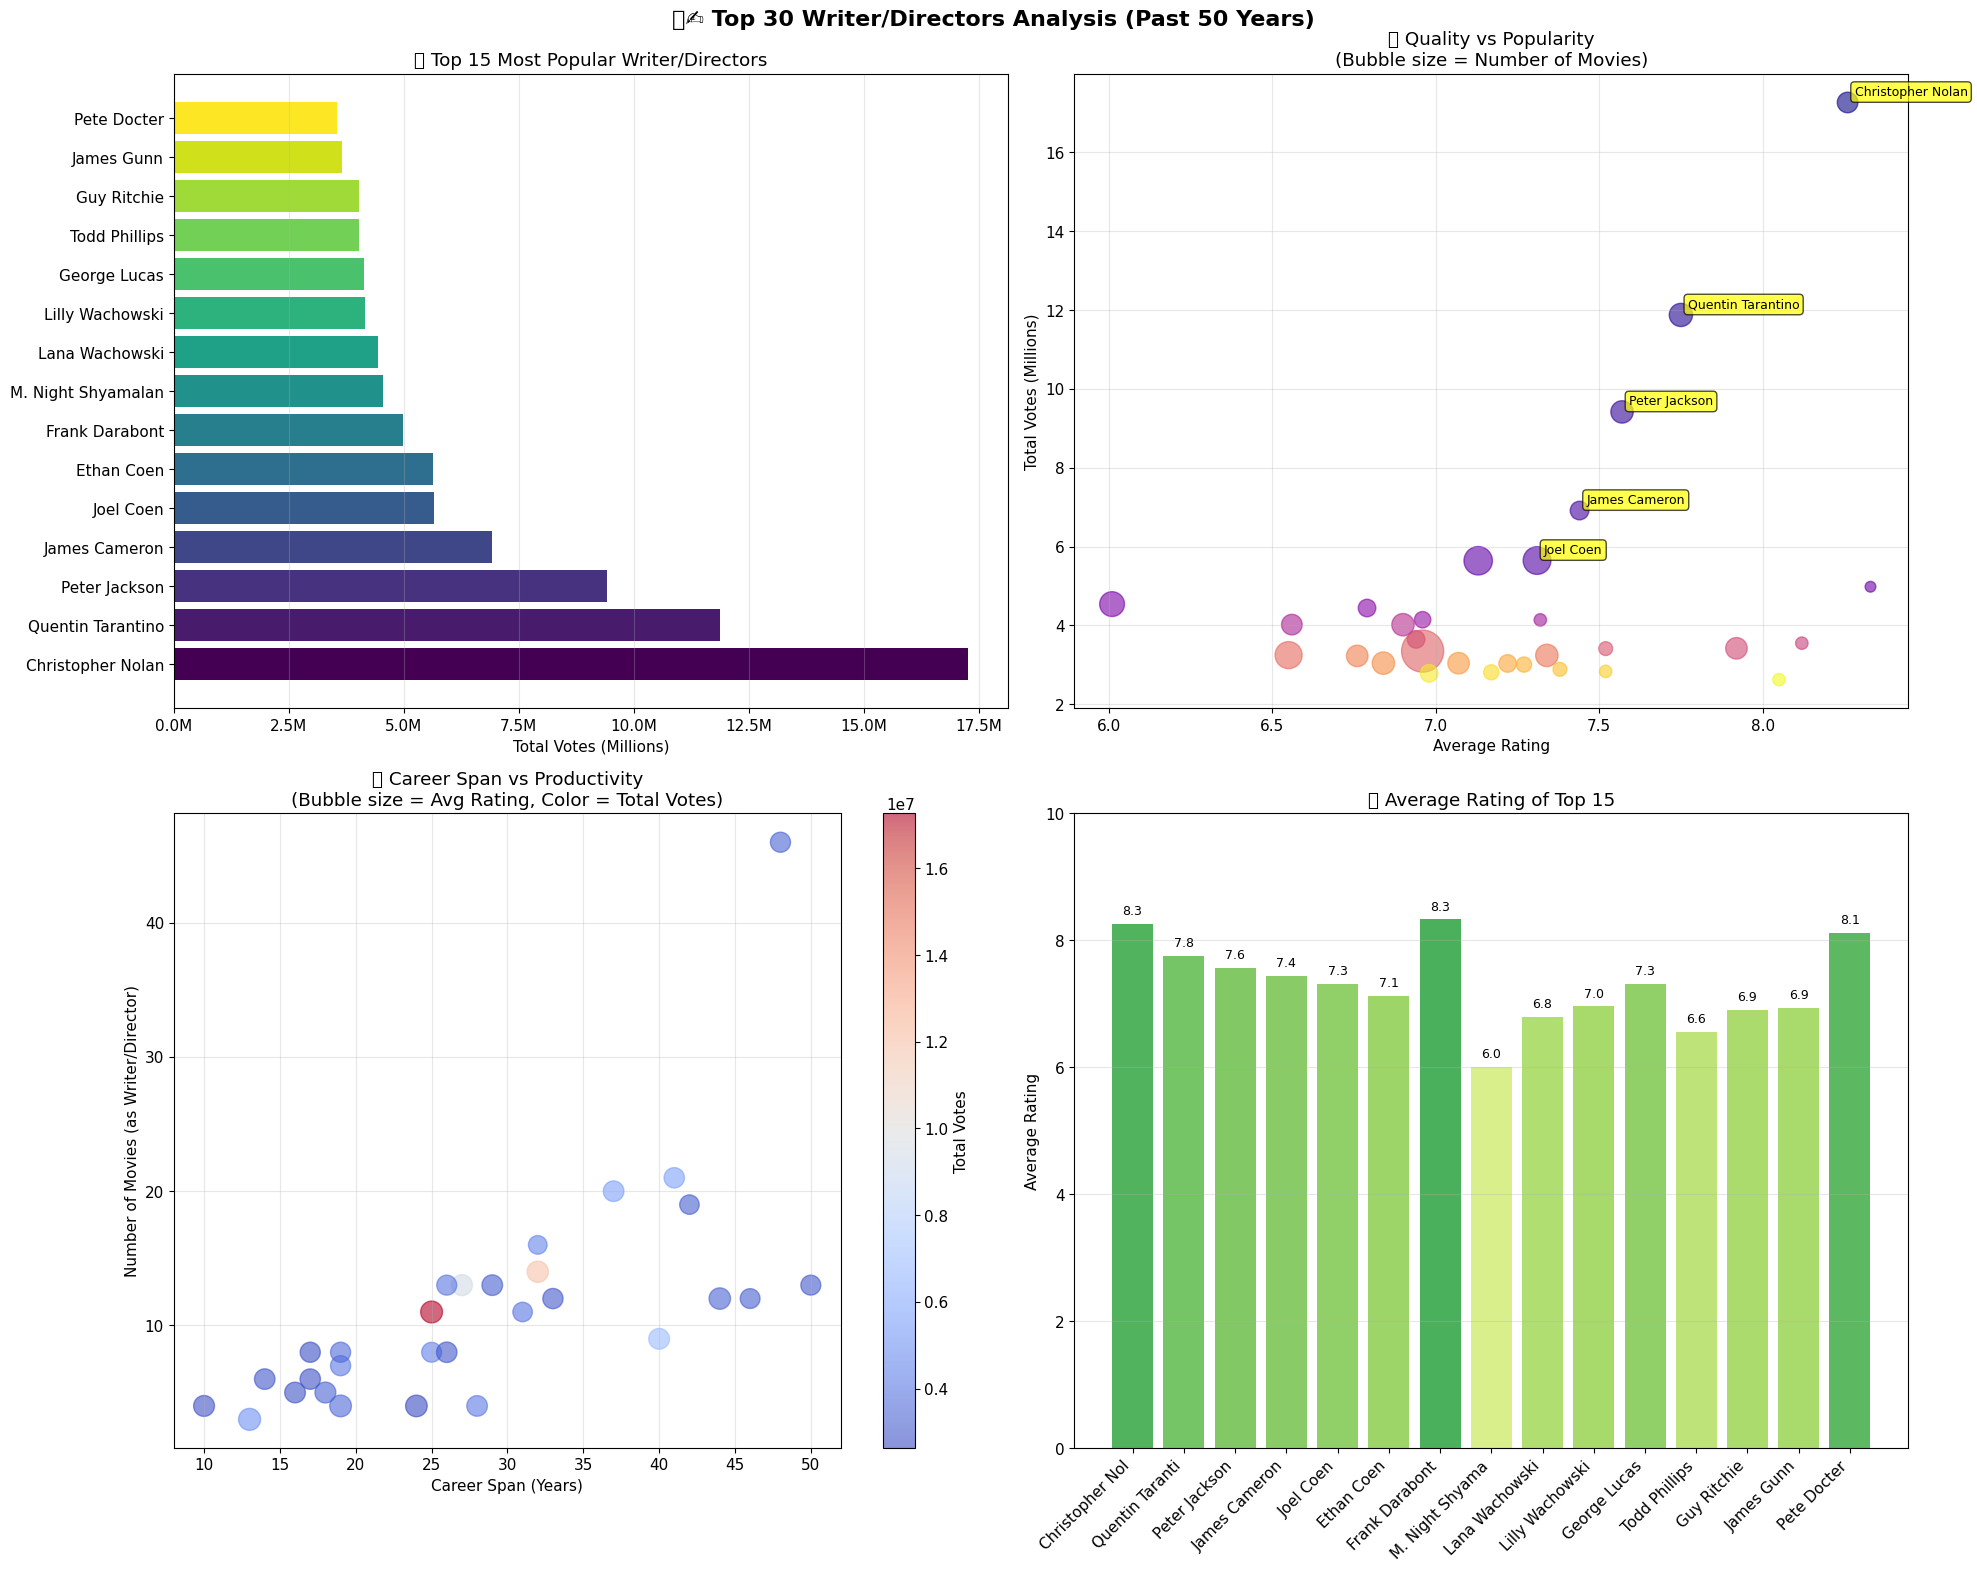


📊 DETAILED STATISTICS:
Average movies per writer/director: 11.2
Average rating: 7.26
Average career span: 28.3 years
Total votes for top 30: 140,239,312

🎯 NOTABLE PATTERNS:
🏆 Most prolific: Woody Allen
   46 movies as writer/director

⭐ Highest rated: Frank Darabont
   Average rating: 8.33

📈 Most popular: Christopher Nolan
   Total votes: 17,265,707

⏰ Longest career: Francis Ford Coppola
   50 years (1974-2024)

🎬 SAMPLE FILMOGRAPHIES (Top 3):

1. Christopher Nolan - Top 5 Most Popular Films:
   1. The Dark Knight (2008) - Rating: 9.1, Votes: 3,079,053
   2. Inception (2010) - Rating: 8.8, Votes: 2,734,473
   3. Interstellar (2014) - Rating: 8.7, Votes: 2,411,287
   4. The Dark Knight Rises (2012) - Rating: 8.4, Votes: 1,944,414
   5. Batman Begins (2005) - Rating: 8.2, Votes: 1,673,167

2. Quentin Tarantino - Top 5 Most Popular Films:
   1. Pulp Fiction (1994) - Rating: 8.8, Votes: 2,372,232
   2. Django Unchained (2012) - Rating: 8.5, Votes: 1,825,553
   3. Inglourious Basterds (

In [10]:
# Writer/Director Analysis - Finding the Top Auteurs
print("🎬✍️ TOP WRITER/DIRECTORS ANALYSIS (Past 50 Years)")
print("=" * 60)

# Calculate the cutoff year (50 years ago from 2024)
current_year = 2024
cutoff_year = current_year - 50
print(f"📅 Analyzing movies from {cutoff_year} to {current_year}")

try:
    # Reload movies dataset to avoid variable conflicts
    movies_data = datasets['title_basics'][datasets['title_basics']['titleType'] == 'movie'].copy()
    movies_data = movies_data.merge(datasets['title_ratings'], on='tconst', how='inner')
    
    # Filter movies from past 50 years
    movies_past_50 = movies_data[movies_data['startYear'] >= cutoff_year].copy()
    print(f"🎬 Found {len(movies_past_50):,} movies from past 50 years")
    
    # Get crew data
    crew_data = datasets['title_crew']
    names_data = datasets['name_basics']
    
    # Merge with crew data
    movies_with_crew = movies_past_50.merge(crew_data, on='tconst', how='inner')
    print(f"✅ Matched {len(movies_with_crew):,} movies with crew data")
    
    # Find people who are BOTH writers AND directors on the same movie
    print(f"\n🔍 Identifying writer/directors (auteurs)...")
    
    writer_director_movies = []
    
    for _, row in movies_with_crew.iterrows():
        directors = set()
        writers = set()
        
        # Parse directors
        if pd.notna(row['directors']) and row['directors'] != '\\N':
            directors = set([d.strip() for d in str(row['directors']).split(',')])
        
        # Parse writers
        if pd.notna(row['writers']) and row['writers'] != '\\N':
            writers = set([w.strip() for w in str(row['writers']).split(',')])
        
        # Find people who are both
        writer_directors = directors.intersection(writers)
        
        if writer_directors:
            for person_id in writer_directors:
                writer_director_movies.append({
                    'person_id': person_id,
                    'tconst': row['tconst'],
                    'title': row['primaryTitle'],
                    'year': row['startYear'],
                    'rating': row['averageRating'],
                    'votes': row['numVotes'],
                    'runtime': row['runtimeMinutes'],
                    'genres': row['genres']
                })
    
    # Convert to DataFrame
    wd_df = pd.DataFrame(writer_director_movies)
    
    if len(wd_df) == 0:
        print("❌ No writer/directors found in the data")
    else:
        print(f"✅ Found {wd_df['person_id'].nunique()} unique writer/directors")
        print(f"✅ Total writer/director credits: {len(wd_df):,}")
        
        # Calculate statistics for each writer/director
        wd_stats = wd_df.groupby('person_id').agg({
            'rating': ['mean', 'median', 'std', 'count'],
            'votes': ['sum', 'mean'],
            'year': ['min', 'max'],
            'title': 'count'
        }).round(2)
        
        # Flatten column names
        wd_stats.columns = ['avg_rating', 'median_rating', 'std_rating', 'num_movies',
                            'total_votes', 'avg_votes', 'first_year', 'last_year', 'title_count']
        
        # Calculate additional metrics
        wd_stats['career_span'] = wd_stats['last_year'] - wd_stats['first_year']
        wd_stats['popularity_score'] = wd_stats['total_votes'] / wd_stats['total_votes'].max() * 100
        
        # Filter: at least 3 movies as writer/director
        wd_stats = wd_stats[wd_stats['num_movies'] >= 3]
        
        # Map person IDs to names
        name_mapping = dict(zip(names_data['nconst'], names_data['primaryName']))
        wd_stats['name'] = wd_stats.index.map(name_mapping).fillna('Unknown')
        
        # Sort by popularity (total votes) to get the most popular
        wd_stats_sorted = wd_stats.sort_values('total_votes', ascending=False)
        
        # Get top 30
        top_30_wd = wd_stats_sorted.head(30)
        
        print(f"\n🏆 TOP 30 MOST POPULAR WRITER/DIRECTORS (Past 50 Years)")
        print("=" * 80)
        print(f"{'Rank':<5} {'Name':<30} {'Movies':<8} {'Avg Rating':<12} {'Total Votes':<15} {'Career Span'}")
        print("-" * 80)
        
        for i, (person_id, row) in enumerate(top_30_wd.iterrows(), 1):
            name = row['name'][:28]  # Truncate if too long
            movies_count = int(row['num_movies'])
            rating = row['avg_rating']
            votes = int(row['total_votes'])
            span = f"{int(row['first_year'])}-{int(row['last_year'])}"
            
            print(f"{i:<5} {name:<30} {movies_count:<8} {rating:<12.2f} {votes:<15,} {span}")
        
        # Create visualizations
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
        fig.suptitle('🎬✍️ Top 30 Writer/Directors Analysis (Past 50 Years)', 
                     fontsize=16, fontweight='bold')
        
        # 1. Top 15 by Popularity (Total Votes)
        top_15 = top_30_wd.head(15)
        colors_pop = plt.cm.viridis(np.linspace(0, 1, 15))
        bars1 = ax1.barh(range(15), top_15['total_votes'], color=colors_pop)
        ax1.set_yticks(range(15))
        ax1.set_yticklabels(top_15['name'])
        ax1.set_xlabel('Total Votes (Millions)')
        ax1.set_title('📊 Top 15 Most Popular Writer/Directors')
        ax1.grid(axis='x', alpha=0.3)
        
        # Format x-axis to show millions
        ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
        
        # 2. Popularity vs Quality
        scatter1 = ax2.scatter(top_30_wd['avg_rating'], top_30_wd['total_votes']/1e6,
                              s=top_30_wd['num_movies']*20, alpha=0.6, 
                              c=range(len(top_30_wd)), cmap='plasma')
        ax2.set_xlabel('Average Rating')
        ax2.set_ylabel('Total Votes (Millions)')
        ax2.set_title('⭐ Quality vs Popularity\n(Bubble size = Number of Movies)')
        ax2.grid(alpha=0.3)
        
        # Annotate top 5
        for i, (idx, row) in enumerate(top_30_wd.head(5).iterrows()):
            ax2.annotate(row['name'], 
                        (row['avg_rating'], row['total_votes']/1e6),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, bbox=dict(boxstyle='round,pad=0.3', 
                                             facecolor='yellow', alpha=0.7))
        
        # 3. Career Span vs Number of Movies
        scatter2 = ax3.scatter(top_30_wd['career_span'], top_30_wd['num_movies'],
                              s=top_30_wd['avg_rating']*30, alpha=0.6,
                              c=top_30_wd['total_votes'], cmap='coolwarm')
        ax3.set_xlabel('Career Span (Years)')
        ax3.set_ylabel('Number of Movies (as Writer/Director)')
        ax3.set_title('⏱️ Career Span vs Productivity\n(Bubble size = Avg Rating, Color = Total Votes)')
        ax3.grid(alpha=0.3)
        plt.colorbar(scatter2, ax=ax3, label='Total Votes')
        
        # 4. Rating Distribution
        rating_colors = plt.cm.RdYlGn(top_15['avg_rating'] / 10)
        bars2 = ax4.bar(range(15), top_15['avg_rating'], color=rating_colors)
        ax4.set_xticks(range(15))
        ax4.set_xticklabels([name[:15] for name in top_15['name']], 
                           rotation=45, ha='right')
        ax4.set_ylabel('Average Rating')
        ax4.set_title('⭐ Average Rating of Top 15')
        ax4.set_ylim(0, 10)
        ax4.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, (bar, rating) in enumerate(zip(bars2, top_15['avg_rating'])):
            ax4.text(i, rating + 0.1, f'{rating:.1f}', 
                    ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # Detailed statistics
        print(f"\n📊 DETAILED STATISTICS:")
        print("=" * 60)
        print(f"Average movies per writer/director: {top_30_wd['num_movies'].mean():.1f}")
        print(f"Average rating: {top_30_wd['avg_rating'].mean():.2f}")
        print(f"Average career span: {top_30_wd['career_span'].mean():.1f} years")
        print(f"Total votes for top 30: {top_30_wd['total_votes'].sum():,}")
        
        # Identify notable patterns
        print(f"\n🎯 NOTABLE PATTERNS:")
        print("=" * 40)
        
        most_prolific = top_30_wd.loc[top_30_wd['num_movies'].idxmax()]
        highest_rated = top_30_wd.loc[top_30_wd['avg_rating'].idxmax()]
        most_popular = top_30_wd.iloc[0]
        longest_career = top_30_wd.loc[top_30_wd['career_span'].idxmax()]
        
        print(f"🏆 Most prolific: {most_prolific['name']}")
        print(f"   {int(most_prolific['num_movies'])} movies as writer/director")
        print(f"\n⭐ Highest rated: {highest_rated['name']}")
        print(f"   Average rating: {highest_rated['avg_rating']:.2f}")
        print(f"\n📈 Most popular: {most_popular['name']}")
        print(f"   Total votes: {int(most_popular['total_votes']):,}")
        print(f"\n⏰ Longest career: {longest_career['name']}")
        print(f"   {int(longest_career['career_span'])} years ({int(longest_career['first_year'])}-{int(longest_career['last_year'])})")
        
        # Show sample filmography for top 3
        print(f"\n🎬 SAMPLE FILMOGRAPHIES (Top 3):")
        print("=" * 60)
        
        for i, (person_id, row) in enumerate(top_30_wd.head(3).iterrows(), 1):
            person_movies = wd_df[wd_df['person_id'] == person_id].sort_values('votes', ascending=False).head(5)
            print(f"\n{i}. {row['name']} - Top 5 Most Popular Films:")
            for j, (_, movie) in enumerate(person_movies.iterrows(), 1):
                print(f"   {j}. {movie['title']} ({int(movie['year'])}) - "
                      f"Rating: {movie['rating']:.1f}, Votes: {int(movie['votes']):,}")
        
        print(f"\n✅ Analysis complete!")
        
except Exception as e:
    print(f"❌ Error in writer/director analysis: {e}")
    import traceback
    traceback.print_exc()

## 8. 🌍 Regional & Language Data Analysis - Global Movie Distribution

🌍 REGIONAL & LANGUAGE DATA EXPLORATION
✅ Regional data loaded successfully!
📊 Total records: 3,573,412
🎬 Unique movies: 724,967

📋 Sample regional data:
      tconst  ordering                               title region language  \
0  tt0000009         1                          Miss Jerry   None     None   
1  tt0000009         2                          Miss Jerry     AU     None   
2  tt0000009         3                          Miss Jerry     HU     None   
3  tt0000009         4                          Miss Jerry     US     None   
4  tt0000009         5                      Fräulein Jerry     DE     None   
5  tt0000009         6                        Preili Jerry     EE     None   
6  tt0000147         1       The Corbett-Fitzsimmons Fight   None     None   
7  tt0000147         2  Corbeti ja Fitzsimmoni kahevõitlus     EE     None   
8  tt0000147         3       The Corbett-Fitzsimmons Fight     US     None   
9  tt0000147         4         Бой Корбетта и Фитцсиммонса     RU  

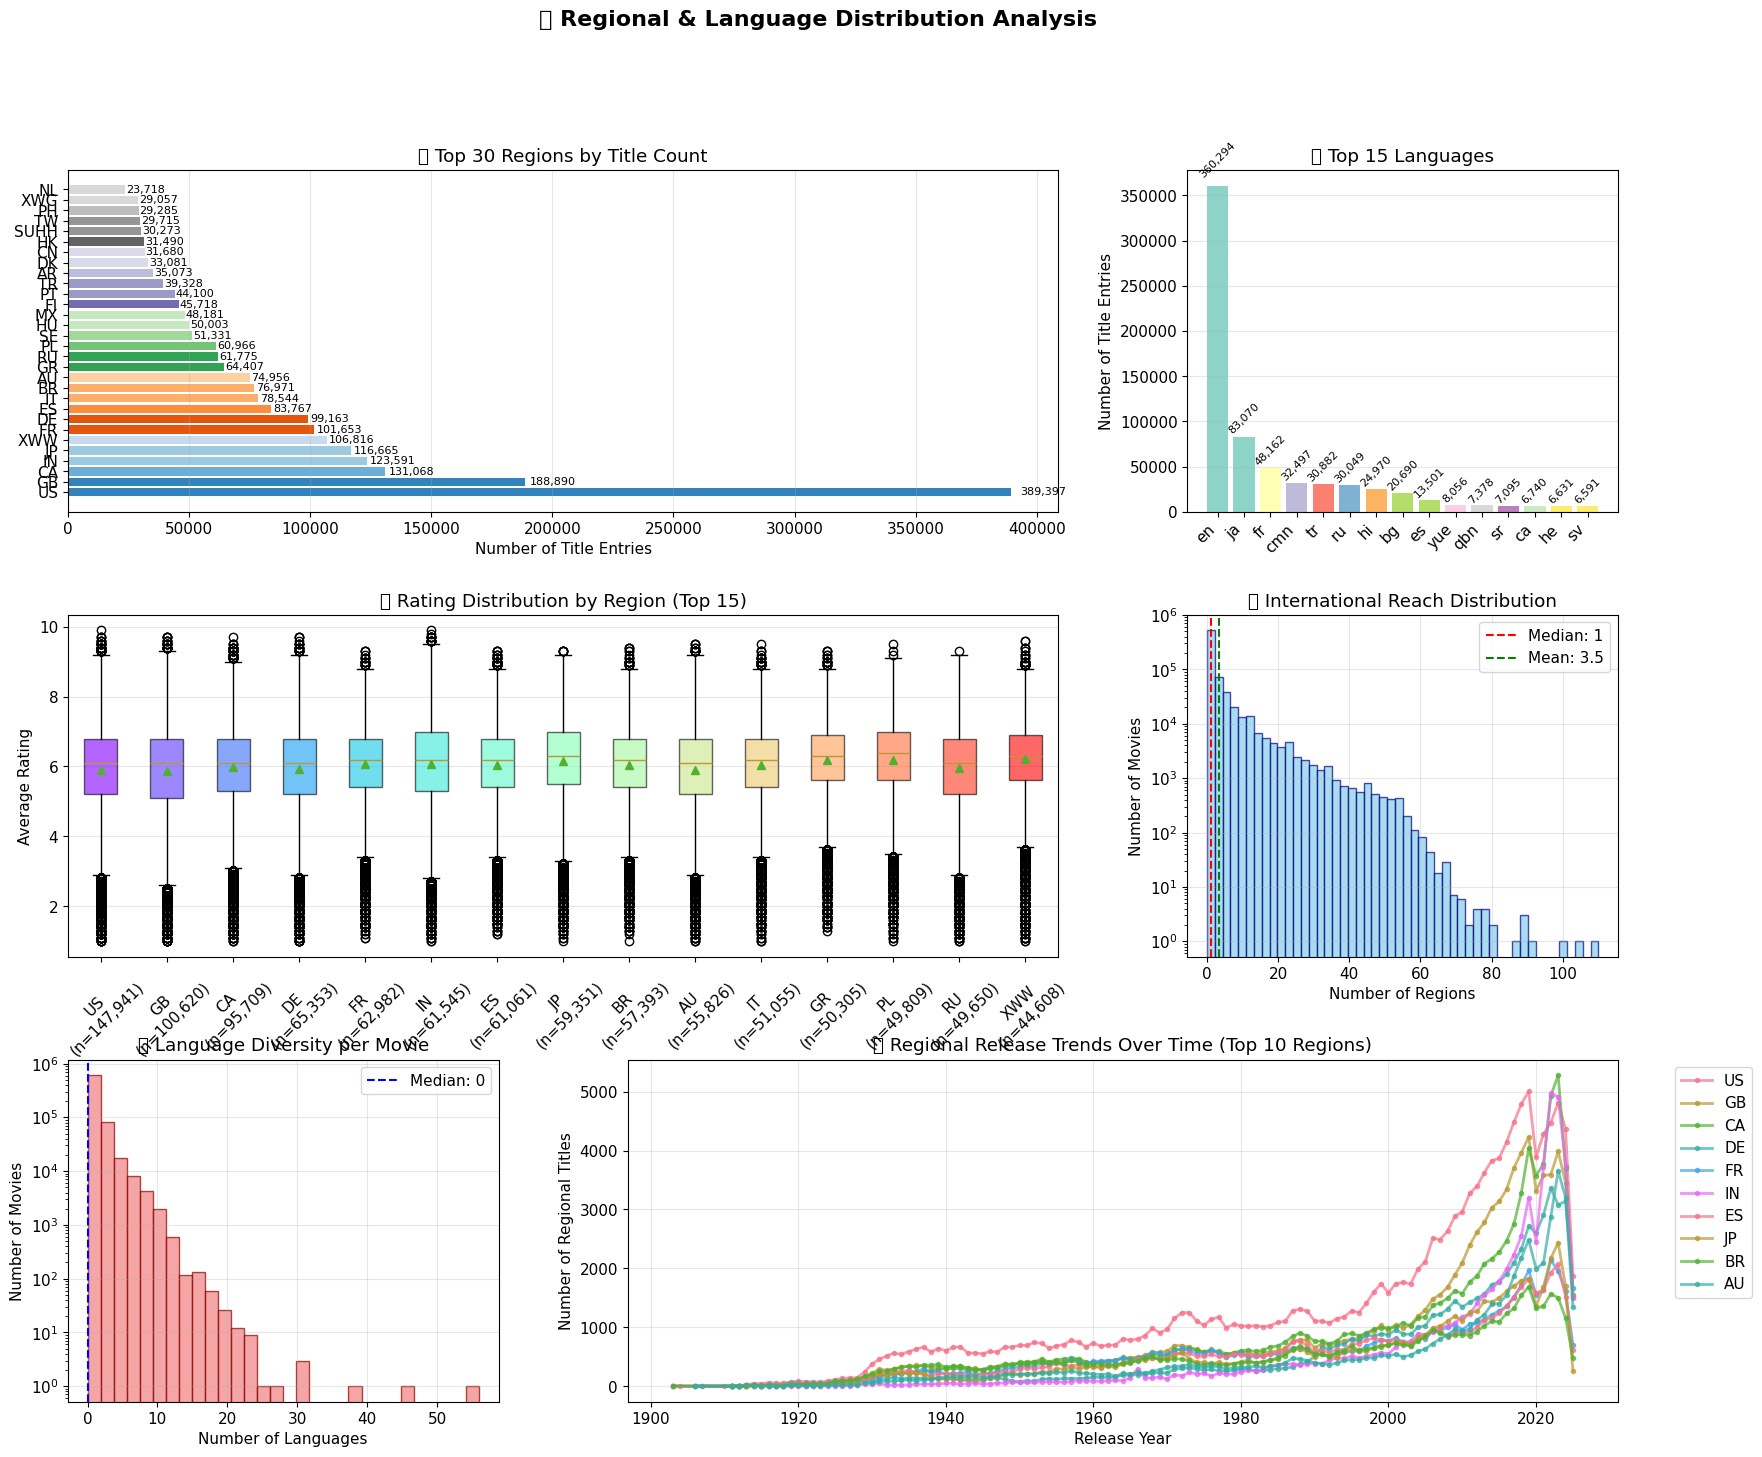


📊 DETAILED REGIONAL ANALYSIS:

🌍 TOP 20 REGIONS:
------------------------------------------------------------
 1. US    -  389,397 entries (10.90%)
 2. GB    -  188,890 entries ( 5.29%)
 3. CA    -  131,068 entries ( 3.67%)
 4. IN    -  123,591 entries ( 3.46%)
 5. JP    -  116,665 entries ( 3.26%)
 6. XWW   -  106,816 entries ( 2.99%)
 7. FR    -  101,653 entries ( 2.84%)
 8. DE    -   99,163 entries ( 2.78%)
 9. ES    -   83,767 entries ( 2.34%)
10. IT    -   78,544 entries ( 2.20%)
11. BR    -   76,971 entries ( 2.15%)
12. AU    -   74,956 entries ( 2.10%)
13. GR    -   64,407 entries ( 1.80%)
14. RU    -   61,775 entries ( 1.73%)
15. PL    -   60,966 entries ( 1.71%)
16. SE    -   51,331 entries ( 1.44%)
17. HU    -   50,003 entries ( 1.40%)
18. MX    -   48,181 entries ( 1.35%)
19. FI    -   45,718 entries ( 1.28%)
20. PT    -   44,100 entries ( 1.23%)

🗣️  TOP 20 LANGUAGES:
------------------------------------------------------------
 1. en         -  360,294 entries (10.08%)
 2

In [15]:
# Regional & Language Data Exploration
print("🌍 REGIONAL & LANGUAGE DATA EXPLORATION")
print("=" * 60)

# Check if regional data is available
if 'title_akas' not in datasets:
    print("❌ Regional data (title_akas) is not available.")
    print("Run data_collection.py and preprocessing.py to download and process regional data.")
else:
    akas_df = datasets['title_akas']
    
    print(f"✅ Regional data loaded successfully!")
    print(f"📊 Total records: {len(akas_df):,}")
    print(f"🎬 Unique movies: {akas_df['tconst'].nunique():,}")
    
    # Display sample data
    print(f"\n📋 Sample regional data:")
    print(akas_df.head(10))
    
    print(f"\n📋 Data structure:")
    print(f"Columns: {list(akas_df.columns)}")
    print(f"\nData types:")
    print(akas_df.dtypes)
    
    # Basic statistics
    print(f"\n📊 BASIC STATISTICS:")
    print("=" * 40)
    
    if 'region' in akas_df.columns:
        print(f"• Total regions: {akas_df['region'].nunique()}")
        print(f"• Records with region info: {akas_df['region'].notna().sum():,}")
    
    if 'language' in akas_df.columns:
        print(f"• Total languages: {akas_df['language'].nunique()}")
        print(f"• Records with language info: {akas_df['language'].notna().sum():,}")
    
    if 'types' in akas_df.columns:
        print(f"• Title types: {akas_df['types'].unique()}")
    
    # Merge with movie ratings for analysis
    print(f"\n🔗 Merging with movie ratings...")
    akas_with_ratings = akas_df.merge(
        movies[['tconst', 'primaryTitle', 'startYear', 'averageRating', 'numVotes', 'genres']], 
        on='tconst', 
        how='inner'
    )
    print(f"✅ Merged {len(akas_with_ratings):,} regional records with movie ratings")
    
    # Create comprehensive visualizations
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Top Regions by Movie Count
    if 'region' in akas_df.columns:
        ax1 = fig.add_subplot(gs[0, :2])
        top_30_regions = akas_df['region'].value_counts().head(30)
        colors_regions = plt.cm.tab20c(np.linspace(0, 1, len(top_30_regions)))
        
        bars = ax1.barh(range(len(top_30_regions)), top_30_regions.values, color=colors_regions)
        ax1.set_yticks(range(len(top_30_regions)))
        ax1.set_yticklabels(top_30_regions.index)
        ax1.set_xlabel('Number of Title Entries')
        ax1.set_title('🌍 Top 30 Regions by Title Count')
        ax1.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, (region, count) in enumerate(zip(top_30_regions.index, top_30_regions.values)):
            ax1.text(count + count*0.01, i, f'{count:,}', va='center', ha='left', fontsize=8)
    
    # 2. Top Languages by Movie Count
    if 'language' in akas_df.columns:
        ax2 = fig.add_subplot(gs[0, 2])
        top_15_languages = akas_df['language'].value_counts().head(15)
        colors_lang = plt.cm.Set3(np.linspace(0, 1, len(top_15_languages)))
        
        bars = ax2.bar(range(len(top_15_languages)), top_15_languages.values, color=colors_lang)
        ax2.set_xticks(range(len(top_15_languages)))
        ax2.set_xticklabels(top_15_languages.index, rotation=45, ha='right')
        ax2.set_ylabel('Number of Title Entries')
        ax2.set_title('🗣️ Top 15 Languages')
        ax2.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, (lang, count) in enumerate(zip(top_15_languages.index, top_15_languages.values)):
            ax2.text(i, count + count*0.02, f'{count:,}', ha='center', va='bottom', fontsize=8, rotation=45)
    
    # 3. Regional Distribution by Rating
    if 'region' in akas_with_ratings.columns:
        ax3 = fig.add_subplot(gs[1, :2])
        
        # Get top 15 regions
        top_regions_for_rating = akas_with_ratings['region'].value_counts().head(15).index
        region_ratings = []
        region_labels = []
        
        for region in top_regions_for_rating:
            ratings = akas_with_ratings[akas_with_ratings['region'] == region]['averageRating'].dropna()
            if len(ratings) > 10:  # Only regions with sufficient data
                region_ratings.append(ratings)
                region_labels.append(f"{region}\n(n={len(ratings):,})")
        
        if region_ratings:
            bp = ax3.boxplot(region_ratings, labels=region_labels, patch_artist=True, showmeans=True)
            
            # Color boxes
            colors_box = plt.cm.rainbow(np.linspace(0, 1, len(region_ratings)))
            for patch, color in zip(bp['boxes'], colors_box):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            
            ax3.set_ylabel('Average Rating')
            ax3.set_title('⭐ Rating Distribution by Region (Top 15)')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(axis='y', alpha=0.3)
    
    # 4. Movies per Region (International Reach)
    if 'region' in akas_df.columns:
        ax4 = fig.add_subplot(gs[1, 2])
        
        # Count how many regions each movie appears in
        regions_per_movie = akas_df.groupby('tconst')['region'].nunique()
        
        ax4.hist(regions_per_movie, bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
        ax4.set_xlabel('Number of Regions')
        ax4.set_ylabel('Number of Movies')
        ax4.set_title('📊 International Reach Distribution')
        ax4.set_yscale('log')
        ax4.grid(alpha=0.3)
        
        # Add statistics
        ax4.axvline(regions_per_movie.median(), color='red', linestyle='--', 
                   label=f'Median: {regions_per_movie.median():.0f}')
        ax4.axvline(regions_per_movie.mean(), color='green', linestyle='--', 
                   label=f'Mean: {regions_per_movie.mean():.1f}')
        ax4.legend()
    
    # 5. Language Diversity per Movie
    if 'language' in akas_df.columns:
        ax5 = fig.add_subplot(gs[2, 0])
        
        # Count how many languages each movie has
        languages_per_movie = akas_df.groupby('tconst')['language'].nunique()
        
        ax5.hist(languages_per_movie, bins=30, color='lightcoral', edgecolor='darkred', alpha=0.7)
        ax5.set_xlabel('Number of Languages')
        ax5.set_ylabel('Number of Movies')
        ax5.set_title('🗣️ Language Diversity per Movie')
        ax5.set_yscale('log')
        ax5.grid(alpha=0.3)
        
        # Add statistics
        ax5.axvline(languages_per_movie.median(), color='blue', linestyle='--', 
                   label=f'Median: {languages_per_movie.median():.0f}')
        ax5.legend()
    
    # 6. Regional Release Patterns Over Time
    if 'region' in akas_with_ratings.columns and 'startYear' in akas_with_ratings.columns:
        ax6 = fig.add_subplot(gs[2, 1:])
        
        # Get top 10 regions
        top_10_regions = akas_with_ratings['region'].value_counts().head(10).index
        
        for region in top_10_regions:
            region_data = akas_with_ratings[akas_with_ratings['region'] == region]
            yearly_counts = region_data.groupby('startYear').size()
            
            # Smooth the data a bit
            if len(yearly_counts) > 5:
                ax6.plot(yearly_counts.index, yearly_counts.values, marker='o', 
                        markersize=3, alpha=0.7, label=region, linewidth=2)
        
        ax6.set_xlabel('Release Year')
        ax6.set_ylabel('Number of Regional Titles')
        ax6.set_title('📈 Regional Release Trends Over Time (Top 10 Regions)')
        ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax6.grid(alpha=0.3)
    
    plt.suptitle('🌍 Regional & Language Distribution Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Statistical Analysis
    print(f"\n📊 DETAILED REGIONAL ANALYSIS:")
    print("=" * 60)
    
    if 'region' in akas_df.columns:
        print(f"\n🌍 TOP 20 REGIONS:")
        print("-" * 60)
        top_20_regions_detailed = akas_df['region'].value_counts().head(20)
        for i, (region, count) in enumerate(top_20_regions_detailed.items(), 1):
            percentage = (count / len(akas_df)) * 100
            print(f"{i:2d}. {region:5s} - {count:8,} entries ({percentage:5.2f}%)")
    
    if 'language' in akas_df.columns:
        print(f"\n🗣️  TOP 20 LANGUAGES:")
        print("-" * 60)
        top_20_languages_detailed = akas_df['language'].value_counts().head(20)
        for i, (lang, count) in enumerate(top_20_languages_detailed.items(), 1):
            percentage = (count / len(akas_df)) * 100
            print(f"{i:2d}. {lang:10s} - {count:8,} entries ({percentage:5.2f}%)")
    
    # Movies with widest international reach
    print(f"\n🌐 MOVIES WITH WIDEST INTERNATIONAL REACH:")
    print("=" * 60)
    
    if 'region' in akas_df.columns:
        wide_release_movies = akas_df.groupby('tconst').agg({
            'region': 'nunique',
            'language': 'nunique' if 'language' in akas_df.columns else lambda x: None
        }).reset_index()
        
        wide_release_movies.columns = ['tconst', 'num_regions', 'num_languages']
        wide_release_movies = wide_release_movies.merge(
            movies[['tconst', 'primaryTitle', 'startYear', 'averageRating', 'numVotes']], 
            on='tconst', 
            how='inner'
        )
        
        # Sort by number of regions
        top_wide_release = wide_release_movies.nlargest(15, 'num_regions')
        
        print(f"{'Rank':<5} {'Title':<40} {'Year':<6} {'Regions':<10} {'Languages':<10} {'Rating'}")
        print("-" * 100)
        for i, (_, movie) in enumerate(top_wide_release.iterrows(), 1):
            title = movie['primaryTitle'][:38]
            year = int(movie['startYear']) if pd.notna(movie['startYear']) else 'N/A'
            regions = int(movie['num_regions'])
            languages = int(movie['num_languages']) if pd.notna(movie['num_languages']) else 0
            rating = movie['averageRating']
            
            print(f"{i:<5} {title:<40} {year:<6} {regions:<10} {languages:<10} {rating:.1f}")
    
    # Regional rating insights
    if 'region' in akas_with_ratings.columns:
        print(f"\n⭐ AVERAGE RATING BY REGION (Top 20):")
        print("=" * 60)
        
        region_rating_stats = akas_with_ratings.groupby('region').agg({
            'averageRating': ['mean', 'median', 'count']
        }).round(2)
        
        region_rating_stats.columns = ['avg_rating', 'median_rating', 'count']
        region_rating_stats = region_rating_stats[region_rating_stats['count'] >= 100]  # Min 100 movies
        region_rating_stats = region_rating_stats.sort_values('avg_rating', ascending=False).head(20)
        
        print(f"{'Rank':<5} {'Region':<10} {'Movies':<10} {'Avg Rating':<12} {'Median Rating'}")
        print("-" * 60)
        for i, (region, stats) in enumerate(region_rating_stats.iterrows(), 1):
            print(f"{i:<5} {region:<10} {int(stats['count']):<10} {stats['avg_rating']:<12.2f} {stats['median_rating']:.2f}")
    
    # Key insights
    print(f"\n💡 KEY INSIGHTS:")
    print("=" * 60)
    
    if 'region' in akas_df.columns:
        total_regions = akas_df['region'].nunique()
        avg_regions_per_movie = regions_per_movie.mean()
        max_regions = regions_per_movie.max()
        
        print(f"✅ Movies are distributed across {total_regions} different regions")
        print(f"✅ Average movie appears in {avg_regions_per_movie:.1f} regions")
        print(f"✅ Most widely distributed movie appears in {int(max_regions)} regions")
    
    if 'language' in akas_df.columns:
        total_languages = akas_df['language'].nunique()
        avg_languages_per_movie = languages_per_movie.mean()
        
        print(f"✅ Content available in {total_languages} different languages")
        print(f"✅ Average movie has titles in {avg_languages_per_movie:.1f} languages")
    
    print(f"\n🎬 Regional data can be valuable for:")
    print("   • Understanding global movie distribution patterns")
    print("   • Identifying region-specific preferences")
    print("   • Feature engineering: international reach metrics")
    print("   • Market analysis and expansion strategies")
    
    print(f"\n✅ Regional data exploration complete!")
